# Evolutionary Algorithms for Adaptive Business Rule Optimization
## TransUnion Capstone — IDS 560 | Combined GA Pipeline (Synthetic Dataset)

---

### What This Notebook Does

This is the **unified pipeline** adapted for the synthetic fraud dataset with real variable names.
All GA logic, constraints, and evaluation methods are identical to the Kaggle pipeline.

| Stage | Description |
|---|---|
| **1. Data** | Load and clean the synthetic fraud dataset |
| **2. Splits** | Stratified random split OR time-ordered split |
| **3. Feature Engineering** | Device_Risk_Score decile binning + categorical encoding + MI screening |
| **4. Baseline GA** | Single AND-rule evolution (Algorithm v1) |
| **5. Coevolution GA** | OR-of-AND rule set evolution (Algorithm v2) |
| **6. Pareto Front** | Three operating points: Conservative / Balanced / Aggressive |
| **7. Stability** | Multi-seed reproducibility analysis |
| **8. Outputs** | JSON + CSV + plots saved to `/content/outputs_synthetic` |

### Key Differences from Kaggle Pipeline
| Item | Kaggle Pipeline | This Pipeline |
|---|---|---|
| Label column | `Class` | `Fraud_Label` renamed to `Class` on load |
| ID column | None | `Transaction_ID` dropped on load |
| Timestamp | `Time` (seconds elapsed) | Simulated `Time` column added externally |
| Binned feature | `V10` → `V10_bin_code` | `Device_Risk_Score` → `Device_Risk_Score_bin` |
| Categorical features | None (all numeric) | 13 string columns label-encoded before GA |
| Feature names | Anonymous (V1-V28) | Interpretable real names |


---
## Section 0: Configuration

All parameters are defined here. Adjust before running.

| Parameter | Default | Meaning |
|---|---|---|
| `SPLIT_MODE` | `"stratified"` | `"stratified"` or `"time_ordered"` |
| `EXCLUDE_TIME_FEATURES` | `True` | Remove simulated Time column from feature pool |
| `TOP_K` | `12` | Number of top features after MI screening |
| `RUN_BASELINE_GA` | `True` | Run Algorithm v1 (single AND-rule) |
| `RUN_COEVOLUTION` | `True` | Run Algorithm v2 (OR-of-AND rule sets) |
| `RUN_STABILITY` | `True` | Run 5-seed stability analysis |


In [1]:
import os

# -- Split mode ---------------------------------------------------------------
# 'stratified'   -> random stratified 70/15/15 split (recommended for synthetic data)
# 'time_ordered' -> sort by simulated Time column (artificial ordering on synthetic data)
SPLIT_MODE = "time_ordered"

# -- Feature settings ---------------------------------------------------------
EXCLUDE_TIME_FEATURES = True   # Drop simulated Time column from GA feature pool
TOP_K                 = 12     # Top features retained after MI screening

# -- Seeds --------------------------------------------------------------------
RANDOM_SEED     = 42
STABILITY_SEEDS = [11, 22, 33, 44, 55]

# -- Run flags ----------------------------------------------------------------
RUN_BASELINE_GA = True
RUN_COEVOLUTION = True
RUN_STABILITY   = True
RUN_NSGA2       = True

# -- GA hyperparameters -------------------------------------------------------
BASELINE_POP_SIZE    = 80
BASELINE_GENS        = 80
EARLY_STOP_PATIENCE  = 10   # stop if best F1 flat for this many gens
MAX_NODES_PER_PATH   = 10
MAX_PATHS_PER_RS     = 16
PATH_POP_SIZE        = 60
RULESET_POP_SIZE     = 40
NSGA2_POP_SIZE       = 100  # population size for NSGA-II (larger for Pareto coverage)
NSGA2_GENS           = 80   # generations for NSGA-II
COEVO_CYCLES         = 80
INNER_PATH_GENS      = 10
INNER_RS_GENS        = 10
N_MIGRATE            = 10
HOF_SIZE             = 5
PATH_POP_CAP         = 120
COVERAGE_LAMBDA      = 0.05
PARSIMONY_MU         = 0.02
MIN_TP_FITNESS       = 5
ALPHA                = 0.01

# -- Greedy builder hyperparameters --------------------------------------------------
RUN_GREEDY        = True
GREEDY_LAMBDA     = 1.0
GREEDY_GAMMA      = 0.5
GREEDY_MAX_RULES  = 10
GREEDY_MIN_NEW_TP = 1

OUTPUT_DIR = r"C:/Users/schyu/Downloads/OneDrive_1_3-10-2026/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Split mode:            {SPLIT_MODE}")
print(f"Exclude Time features: {EXCLUDE_TIME_FEATURES}")
print(f"Top-K features:        {TOP_K}")
print(f"Output directory:      {OUTPUT_DIR}")


Split mode:            time_ordered
Exclude Time features: True
Top-K features:        12
Output directory:      C:/Users/schyu/Downloads/OneDrive_1_3-10-2026/outputs


---
## Section 1: Imports & Setup


In [2]:
# -- Install dependencies ----------------------------------------------------
!pip install -q deap

import copy
import json
import random
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    mutual_info_score, roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix
)
from deap import base, creator, tools

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print("All imports OK.")



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
All imports OK.


---
## Section 2: Load & Clean Data

### Changes from Kaggle pipeline
- **Label column**: `Fraud_Label` is renamed to `Class` on load so all downstream code is identical.
- **ID column**: `Transaction_ID` is a string key with no predictive signal — dropped on load.
- **Simulated Time**: A `Time` column must be present in the CSV (generated via exponential inter-arrival cumsum). Used only for time-ordered split and excluded from GA features.
- **Categorical columns**: 13 string columns are label-encoded in Section 4 before entering the GA. A reverse lookup dictionary is saved for interpretable rule printing.


In [5]:
# -- Upload synthetic CSV from Colab file picker -----------------------------
# File should be: sample_synthetic_with_time.csv (300,000 rows with Time column)
DATA_FILE = "../data/sample_synthetic_with_time.csv"
df = pd.read_csv(DATA_FILE)
print(f"Loaded file: {DATA_FILE}")

# -- Load & clean -------------------------------------------------------------
df = df.drop_duplicates().reset_index(drop=True)

# Drop Transaction_ID: string key with no predictive value
df = df.drop(columns=["Transaction_ID"], errors="ignore")

# Rename Fraud_Label -> Class so all downstream code is identical to Kaggle pipeline
df = df.rename(columns={"Fraud_Label": "Class"})
df["Class"] = df["Class"].astype(int)

print(f"Dataset shape:  {df.shape}")
print(f"Fraud rate:     {df['Class'].mean():.4f}  ({df['Class'].sum()} fraud cases)")
if "Time" in df.columns:
    print(f"Time range:     {df['Time'].min():.1f}s --- {df['Time'].max():.1f}s  "
          f"({df['Time'].max()/3600:.1f} hours total)")
else:
    print("WARNING: No 'Time' column found. SPLIT_MODE will be forced to 'stratified'.")

Loaded file: ../data/sample_synthetic_with_time.csv
Dataset shape:  (1999, 42)
Fraud rate:     0.0020  (4 fraud cases)
Time range:     0.3s --- 1164.2s  (0.3 hours total)


---
## Section 3: Train / Validation / Test Split

**Stratified (recommended for synthetic data)** — random 70/15/15 split, stratified on `Class`.
Use this as the primary evaluation mode since row ordering in the synthetic dataset is arbitrary.

**Time-ordered** — sorts by the simulated `Time` column: earliest 70% to train, next 15% to val, final 15% to test.
This exercises the same code path as the Kaggle time-ordered split. Note that since `Time` was
synthetically generated, the 'temporal' ordering has no real business meaning — use for code
comparisons only, not as a primary result.


In [6]:
# -- Guard: fall back to stratified if Time column is absent -----------------
# Prevents crash if user uploads dataset without the simulated Time column.
_split_mode = SPLIT_MODE
if _split_mode == "time_ordered" and "Time" not in df.columns:
    print("WARNING: SPLIT_MODE='time_ordered' but no Time column found. Falling back to stratified.")
    _split_mode = "stratified"

X_raw = df.drop(columns=["Class"])
y_raw = df["Class"]

if _split_mode == "time_ordered":
    # Sort by simulated Time and take chronological slices
    df_sorted = df.sort_values("Time").reset_index(drop=True)
    n         = len(df_sorted)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)
    train_df  = df_sorted.iloc[:train_end]
    val_df    = df_sorted.iloc[train_end:val_end]
    test_df   = df_sorted.iloc[val_end:]
    X_train = train_df.drop(columns=["Class"]).reset_index(drop=True)
    y_train = train_df["Class"].reset_index(drop=True)
    X_val   = val_df.drop(columns=["Class"]).reset_index(drop=True)
    y_val   = val_df["Class"].reset_index(drop=True)
    X_test  = test_df.drop(columns=["Class"]).reset_index(drop=True)
    y_test  = test_df["Class"].reset_index(drop=True)
    print("Split mode: TIME-ORDERED")
    print(f"  Train: {len(X_train):,} rows | Val: {len(X_val):,} rows | Test: {len(X_test):,} rows")
else:
    # Stratified random split - preserves fraud rate across all three splits
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_raw, y_raw, test_size=0.15, stratify=y_raw, random_state=RANDOM_SEED
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=(0.15/0.85), stratify=y_temp, random_state=RANDOM_SEED
    )
    X_train = X_train.reset_index(drop=True)
    X_val   = X_val.reset_index(drop=True)
    X_test  = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_val   = y_val.reset_index(drop=True)
    y_test  = y_test.reset_index(drop=True)
    print("Split mode: STRATIFIED (random)")

print(f"\nTrain: {len(X_train):>7,} rows  |  fraud rate = {y_train.mean():.4f}  ({y_train.sum()} frauds)")
print(f"Val:   {len(X_val):>7,} rows  |  fraud rate = {y_val.mean():.4f}  ({y_val.sum()} frauds)")
print(f"Test:  {len(X_test):>7,} rows  |  fraud rate = {y_test.mean():.4f}  ({y_test.sum()} frauds)")


Split mode: TIME-ORDERED
  Train: 1,399 rows | Val: 300 rows | Test: 300 rows

Train:   1,399 rows  |  fraud rate = 0.0021  (3 frauds)
Val:       300 rows  |  fraud rate = 0.0000  (0 frauds)
Test:      300 rows  |  fraud rate = 0.0033  (1 frauds)


---
## Section 4: Feature Engineering

### 4a. Categorical Encoding
13 string columns (e.g. `Merchant_Category`, `Device_Type`, `Card_Type`) are label-encoded to integers
before entering the GA. Encoders are fitted on training data only (no leakage).
A reverse-lookup dictionary saves `int_code -> original_string` for each column so that
`pretty_path()` prints `Merchant_Category = jewelry` instead of `Merchant_Category = 5`.

### 4b. Device_Risk_Score Decile Binning
`Device_Risk_Score` (0-100) has the strongest fraud signal in the synthetic data
(fraud avg 43.8 vs legitimate avg 17.6). We bin it into 10 deciles fitted on training data only
and replace it with ordinal integer `Device_Risk_Score_bin` (0-9). This is the direct
equivalent of `V10_bin_code` in the Kaggle pipeline and enables equality-style conditions.

### 4c. Time Feature Exclusion
The simulated `Time` column is excluded from the GA feature pool when `EXCLUDE_TIME_FEATURES = True`.

### 4d. Feature Screening via Mutual Information
Top `TOP_K` features retained. `Device_Risk_Score_bin` is always kept.


In [7]:
# -- 4a: Categorical Encoding ------------------------------------------------
# Identify all object/string columns. These are the 13 categorical features
# (Merchant_Category, Transaction_Channel, Device_Type, Payment_Method,
#  Country_Code, Account_Type, Card_Presence, Customer_Segment, Merchant_Size,
#  Authentication_Type, Transaction_Day_Of_Week, Card_Type, Email_Provider).
# LabelEncoder maps each category to an integer, fitted on train only.

CAT_COLS = [c for c in X_train.columns if X_train[c].dtype == object]
print(f"Categorical columns found ({len(CAT_COLS)}): {CAT_COLS}")

# Fill any NaN with 'unknown' before encoding
for split in [X_train, X_val, X_test]:
    for col in CAT_COLS:
        split[col] = split[col].fillna("unknown")

# Fit on train, apply to all splits
label_encoders   = {}   # col -> fitted LabelEncoder
cat_label_lookup = {}   # col -> {int_code: original_string} for pretty printing

for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(X_train[col])
    label_encoders[col]  = le
    cat_label_lookup[col] = {i: label for i, label in enumerate(le.classes_)}
    X_train[col] = le.transform(X_train[col])
    known = set(le.classes_)
    for split in [X_val, X_test]:
        split[col] = split[col].apply(
            lambda v: le.transform([v])[0] if v in known else -1
        )

print("\nEncoding complete. Example lookup for Merchant_Category:")
print(cat_label_lookup.get("Merchant_Category", "not found"))


Categorical columns found (13): ['Merchant_Category', 'Transaction_Channel', 'Device_Type', 'Payment_Method', 'Country_Code', 'Account_Type', 'Card_Presence', 'Customer_Segment', 'Merchant_Size', 'Authentication_Type', 'Transaction_Day_Of_Week', 'Card_Type', 'Email_Provider']

Encoding complete. Example lookup for Merchant_Category:
{0: 'clothing', 1: 'electronics', 2: 'entertainment', 3: 'gambling', 4: 'gas_station', 5: 'grocery', 6: 'health', 7: 'jewelry', 8: 'money_transfer', 9: 'online_services', 10: 'restaurant', 11: 'travel'}


In [8]:
# -- 4b: Device_Risk_Score Decile Binning ------------------------------------
# Device_Risk_Score has the strongest fraud signal (fraud avg 43.8 vs legit 17.6).
# Binning into 10 deciles (fitted on train only) replaces the raw 0-100 score
# with an ordinal integer 0-9, enabling equality conditions like
#   Device_Risk_Score_bin = 9  (highest-risk decile)
# This is the direct equivalent of V10_bin_code in the Kaggle pipeline.

BIN_FEATURE     = "Device_Risk_Score"
BIN_FEATURE_OUT = "Device_Risk_Score_bin"

_, drs_bin_edges = pd.qcut(X_train[BIN_FEATURE], q=10, duplicates="drop", retbins=True)
drs_bin_edges[0]  = -np.inf
drs_bin_edges[-1] =  np.inf

def apply_drs_binning(X, edges):
    codes = pd.cut(X[BIN_FEATURE], bins=edges, labels=False, include_lowest=True).astype(int)
    idx   = list(X.columns).index(BIN_FEATURE)
    X     = X.drop(columns=[BIN_FEATURE]).copy()
    X.insert(idx, BIN_FEATURE_OUT, codes.values)
    return X

X_train = apply_drs_binning(X_train, drs_bin_edges)
X_val   = apply_drs_binning(X_val,   drs_bin_edges)
X_test  = apply_drs_binning(X_test,  drs_bin_edges)

# Verify: fraud rate should increase with bin number
drs_rates = X_train.assign(Class=y_train.values).groupby(BIN_FEATURE_OUT)["Class"].agg(["count","mean"])
drs_rates.columns = ["n_transactions", "fraud_rate"]
print(f"Fraud rate by {BIN_FEATURE_OUT} decile bin (train):")
print(drs_rates.to_string())


Fraud rate by Device_Risk_Score_bin decile bin (train):
                       n_transactions  fraud_rate
Device_Risk_Score_bin                            
0                                 280    0.000000
1                                 141    0.000000
2                                 141    0.000000
3                                 139    0.000000
4                                 142    0.007042
5                                 139    0.000000
6                                 140    0.007143
7                                 138    0.000000
8                                 139    0.007194


In [9]:
# -- 4c: Exclude Time features -----------------------------------------------
# The simulated Time column is excluded from the GA feature pool by default.
# Rules referencing a synthetic timestamp would not generalize to production.
# This mirrors the Time exclusion in the Kaggle pipeline.

TIME_FEATURES = {"Time", "Time_scaled", "Time_days"}

if EXCLUDE_TIME_FEATURES:
    drop_cols = [c for c in TIME_FEATURES if c in X_train.columns]
    X_train = X_train.drop(columns=drop_cols)
    X_val   = X_val.drop(columns=drop_cols)
    X_test  = X_test.drop(columns=drop_cols)
    if drop_cols:
        print(f"Excluded Time features: {drop_cols}")
    else:
        print("No Time features present in feature set.")
else:
    print("Time features retained (EXCLUDE_TIME_FEATURES = False)")

print(f"Feature count after Time exclusion: {X_train.shape[1]}")


Excluded Time features: ['Time']
Feature count after Time exclusion: 40


In [11]:
# -- 4d: Feature Screening via Mutual Information ----------------------------
# Rank all remaining features by mutual information (MI) with Class.
# MI is computed on quantile-binned versions of continuous features
# (sklearn mutual_info_score requires discrete inputs).
# A fraud-rate spread tiebreaker breaks ties: features with greater difference
# between highest-fraud and lowest-fraud bin rank higher.
# Device_Risk_Score_bin is always kept even if it falls outside top-K.

def feature_screen(Xtr, ytr, max_bins=10):
    rows = []
    for col in Xtr.columns:
        uniq = Xtr[col].nunique()
        if uniq < 3:
            continue
        try:
            b = pd.qcut(Xtr[col], q=min(max_bins, uniq), duplicates="drop")
        except Exception:
            continue
        tmp = pd.DataFrame({"bin": b, "Class": ytr}).dropna()
        if tmp["bin"].nunique() < 2:
            continue
        spread = float(tmp.groupby("bin", observed=True)["Class"].mean().pipe(
            lambda s: s.max() - s.min()))
        mi = float(mutual_info_score(tmp["bin"].cat.codes, tmp["Class"]))
        rows.append({"feature": col, "mi": mi, "spread": spread})
    return pd.DataFrame(rows).sort_values(["mi", "spread"], ascending=False)

rank_df      = feature_screen(X_train, y_train)
TOP_FEATURES = rank_df["feature"].head(TOP_K).tolist()

if BIN_FEATURE_OUT not in TOP_FEATURES:
    TOP_FEATURES.append(BIN_FEATURE_OUT)
    print(f"Note: {BIN_FEATURE_OUT} added (not in top-{TOP_K} by MI but required).")

X_train = X_train[TOP_FEATURES]
X_val   = X_val[TOP_FEATURES]
X_test  = X_test[TOP_FEATURES]

print(f"\nTop {len(TOP_FEATURES)} features selected:")
print(rank_df.head(TOP_K).to_string(index=False))


Note: Device_Risk_Score_bin added (not in top-12 by MI but required).

Top 13 features selected:
                       feature       mi   spread
           Merchant_Risk_Score 0.004972 0.021583
         Transactions_Last_24h 0.004972 0.021583
     Amount_Deviation_From_Avg 0.004957 0.021429
            Transaction_Amount 0.004957 0.021429
             Geo_Location_Risk 0.004957 0.021429
Days_Since_Last_Address_Change 0.004942 0.021277
              Account_Age_Days 0.004911 0.020979
              Transaction_Hour 0.004641 0.018519
       Transaction_Day_Of_Week 0.004437 0.016854
       Num_Unique_Merchants_7d 0.003698 0.015267
      Behavioral_Anomaly_Score 0.003613 0.014388
          Card_Usage_Frequency 0.003602 0.014286


---
## Section 5: Shared Utilities

Evaluation metrics, rule application, and pretty-printing functions used by both GAs.

### Rule representation
A **condition** is a 3-tuple: `(feature_name, operator, threshold)`

A **path** (AND-rule) is a list of conditions — all must be satisfied.

A **rule set** (OR-of-AND) is a list of paths — any one firing triggers a fraud alert.

### Categorical pretty-printing
When a categorical feature appears in a rule (e.g. `Merchant_Category = 5`),
`pretty_path()` looks up the original string from `cat_label_lookup` and prints
`Merchant_Category = jewelry` — making all evolved rules directly interpretable.


In [12]:
# -- Structural constants ----------------------------------------------------
# CATEGORICAL_FEATURES = engineered bin + all 13 label-encoded string columns.
# Categorical features get the full operator set including '=' (equality),
# which is meaningful for discrete/ordinal values.
# Continuous features get only range operators (>, >=, <, <=).

CATEGORICAL_FEATURES = set([BIN_FEATURE_OUT]) | set(CAT_COLS)
CONTINUOUS_OPS       = [">", ">=", "<", "<="]
CATEGORICAL_OPS      = [">", ">=", "=", "<", "<="]
OP_FUNCS = {
    ">":  lambda x, t: x > t,
    ">=": lambda x, t: x >= t,
    "=":  lambda x, t: x == t,
    "<":  lambda x, t: x < t,
    "<=": lambda x, t: x <= t,
}

FEATURES = list(X_train.columns)

# -- Threshold bank: fitted on training data only ----------------------------
# 19 candidate thresholds per feature (5th-95th percentile quantiles).
# For categorical/bin features, thresholds are the unique integer codes.
# Using training quantiles only prevents leakage.
quantiles      = np.linspace(0.05, 0.95, 19)
threshold_bank = {}
for col in FEATURES:
    if col in CATEGORICAL_FEATURES:
        threshold_bank[col] = np.arange(X_train[col].nunique(), dtype=float)
    else:
        threshold_bank[col] = np.quantile(X_train[col].values, quantiles)

# -- Metrics -----------------------------------------------------------------
def evaluate_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    alert = float(y_pred.sum()) / len(y_pred) if len(y_pred) > 0 else 0.0
    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "precision": prec, "recall": rec, "f1": f1, "alert_rate": alert}

# -- Rule application --------------------------------------------------------
def apply_path(path, Xdf):
    """Returns boolean array: True where ALL conditions in the path are satisfied."""
    mask = np.ones(len(Xdf), dtype=bool)
    for col, op, thr in path:
        mask &= OP_FUNCS[op](Xdf[col].values, thr)
    return mask

def apply_ruleset(ruleset, Xdf):
    """Returns integer array: 1 where ANY path fires."""
    mask = np.zeros(len(Xdf), dtype=bool)
    for path in ruleset:
        mask |= apply_path(path, Xdf)
    return mask.astype(int)

# -- Pretty-print helpers ----------------------------------------------------
# For categorical features, look up original string label from cat_label_lookup.
# For Device_Risk_Score_bin, print the integer bin code.
# For continuous features, print threshold to 4 decimal places.
def pretty_path(path):
    parts = []
    for col, op, thr in path:
        if col == BIN_FEATURE_OUT:
            val = int(thr)
        elif col in cat_label_lookup:
            int_code = int(round(thr))
            val = cat_label_lookup[col].get(int_code, int_code)
        else:
            val = f"{thr:.4f}"
        parts.append(f"{col} {op} {val}")
    return "  AND  ".join(parts)

def pretty_ruleset(ruleset):
    lines = []
    for i, path in enumerate(ruleset, 1):
        lines.append(f"  Rule {i}: {pretty_path(path)}")
    return "\n".join(lines)


# -- Greedy marginal-score helper --------------------------------------------
def marginal_score(fires_p, fires_S, y_arr,
                   lam=GREEDY_LAMBDA, gam=GREEDY_GAMMA, complexity=1):
    """
    Score(p|S) = NewTP(p|S) - lam*NewFP(p|S) - gam*Complexity(p)
    fires_p : boolean vector -- path p fires on each sample
    fires_S : boolean vector -- current rule set fires on each sample
    y_arr   : ground-truth labels (0/1)
    """
    y_arr  = np.asarray(y_arr)
    new_tp = int((fires_p & (y_arr == 1) & ~fires_S).sum())
    new_fp = int((fires_p & (y_arr == 0) & ~fires_S).sum())
    score  = new_tp - lam * new_fp - gam * complexity
    return score, new_tp, new_fp

print(f"Utilities ready. Features ({len(FEATURES)}): {FEATURES}")


Utilities ready. Features (13): ['Merchant_Risk_Score', 'Transactions_Last_24h', 'Amount_Deviation_From_Avg', 'Transaction_Amount', 'Geo_Location_Risk', 'Days_Since_Last_Address_Change', 'Account_Age_Days', 'Transaction_Hour', 'Transaction_Day_Of_Week', 'Num_Unique_Merchants_7d', 'Behavioral_Anomaly_Score', 'Card_Usage_Frequency', 'Device_Risk_Score_bin']


---
## Section 6: Baseline GA — Single Rule Evolution (Algorithm v1)

Each individual is a **single AND-rule** of 1-5 conditions. Fitness = F1 on the validation set.

All logic is identical to the Kaggle pipeline:
- Full operator set (`>`, `>=`, `<`, `<=`, `=`)
- No-duplicate-feature constraint (enforced by `deduplicate_base` after crossover)
- Elitism: best rule always survives
- `MIN_TP_FITNESS` gate: rule must catch >= 5 fraud cases on val to receive non-zero fitness

Rules will now print with real feature names, e.g.:
`Transaction_Amount > 280.50  AND  Device_Risk_Score_bin >= 7  AND  Merchant_Category = jewelry`


In [13]:
if not RUN_BASELINE_GA:
    print("Skipping Baseline GA (RUN_BASELINE_GA = False)")
else:
    # -- Constants ------------------------------------------------------------
    MIN_NODES_BASELINE = 1
    MAX_NODES_BASELINE = 10

    # -- Random condition / rule constructors ---------------------------------
    def random_condition_base(exclude=None):
        exclude   = exclude or set()
        available = [f for f in FEATURES if f not in exclude]
        if not available:
            available = FEATURES
        col = random.choice(available)
        ops = CATEGORICAL_OPS if col in CATEGORICAL_FEATURES else CONTINUOUS_OPS
        return (col, random.choice(ops), float(random.choice(threshold_bank[col])))

    def random_rule_base():
        k = random.randint(MIN_NODES_BASELINE, MAX_NODES_BASELINE)
        rule, used = [], set()
        for _ in range(k):
            cond = random_condition_base(exclude=used)
            rule.append(cond)
            used.add(cond[0])
        return rule

    # -- DEAP setup -----------------------------------------------------------
    if "FitnessMaxBase" not in creator.__dict__:
        creator.create("FitnessMaxBase", base.Fitness, weights=(1.0,))
    if "IndividualBase" not in creator.__dict__:
        creator.create("IndividualBase", list, fitness=creator.FitnessMaxBase)

    base_tb = base.Toolbox()
    base_tb.register("individual", tools.initIterate, creator.IndividualBase, random_rule_base)
    base_tb.register("population", tools.initRepeat, list, base_tb.individual)
    base_tb.register("select",     tools.selTournament, tournsize=3)
    base_tb.register("clone",      copy.deepcopy)

    # -- Fitness: F1 on validation set ----------------------------------------
    def fitness_base(ind):
        y_pred = apply_path(ind, X_val).astype(int)
        if int(y_pred.sum()) == 0 or int((y_pred * np.asarray(y_val)).sum()) < MIN_TP_FITNESS:
            return (0.0,)
        return (f1_score(y_val, y_pred, zero_division=0),)

    # -- Deduplication --------------------------------------------------------
    def deduplicate_base(ind):
        seen, out = set(), []
        for cond in ind:
            if cond[0] not in seen:
                out.append(cond)
                seen.add(cond[0])
        if not out:
            out = [random_condition_base()]
        ind[:] = out
        return ind

    # -- Mutation -------------------------------------------------------------
    def mutate_base(ind):
        op = random.choice(["thr", "flip", "replace", "add", "drop"])
        if op == "thr" and len(ind) > 0:
            i = random.randrange(len(ind))
            col, cur_op, _ = ind[i]
            ind[i] = (col, cur_op, float(random.choice(threshold_bank[col])))
        elif op == "flip" and len(ind) > 0:
            i = random.randrange(len(ind))
            col, cur_op, thr = ind[i]
            pool  = CATEGORICAL_OPS if col in CATEGORICAL_FEATURES else CONTINUOUS_OPS
            other = [o for o in pool if o != cur_op]
            ind[i] = (col, random.choice(other), thr)
        elif op == "replace" and len(ind) > 0:
            i    = random.randrange(len(ind))
            used = {c for c, _, _ in ind} - {ind[i][0]}
            ind[i] = random_condition_base(exclude=used)
        elif op == "add" and len(ind) < MAX_NODES_BASELINE:
            used = {c for c, _, _ in ind}
            ind.append(random_condition_base(exclude=used))
        elif op == "drop" and len(ind) > MIN_NODES_BASELINE:
            ind.pop(random.randrange(len(ind)))
        return (ind,)

    # -- Crossover ------------------------------------------------------------
    def cx_base(ind1, ind2):
        if len(ind1) > 0 and len(ind2) > 0:
            i, j = random.randrange(len(ind1)), random.randrange(len(ind2))
            ind1[i], ind2[j] = copy.deepcopy(ind2[j]), copy.deepcopy(ind1[i])
            deduplicate_base(ind1)
            deduplicate_base(ind2)
        return ind1, ind2

    base_tb.register("evaluate", fitness_base)
    base_tb.register("mutate",   mutate_base)
    base_tb.register("mate",     cx_base)

    # -- Evolution loop -------------------------------------------------------
    def run_baseline_ga(pop_size=BASELINE_POP_SIZE, generations=BASELINE_GENS,
                        patience=EARLY_STOP_PATIENCE):
        pop     = base_tb.population(n=pop_size)
        hof     = tools.HallOfFame(1)
        history = []
        for ind in pop:
            ind.fitness.values = base_tb.evaluate(ind)
        hof.update(pop)
        no_improve   = 0
        best_so_far  = 0.0
        converged_at = generations - 1
        for g in range(generations):
            elite     = [base_tb.clone(hof[0])]
            offspring = list(map(base_tb.clone, base_tb.select(pop, pop_size - 1)))
            for c1, c2 in zip(offspring[::2], offspring[1::2]):
                if random.random() < 0.4:
                    base_tb.mate(c1, c2)
                    del c1.fitness.values, c2.fitness.values
            for ind in offspring:
                if random.random() < 0.4:
                    base_tb.mutate(ind)
                    del ind.fitness.values
            for ind in offspring:
                if not ind.fitness.valid:
                    ind.fitness.values = base_tb.evaluate(ind)
            pop[:] = elite + offspring
            hof.update(pop)
            best_f1 = hof[0].fitness.values[0]
            avg_f1  = float(np.mean([ind.fitness.values[0] for ind in pop]))
            history.append({"gen": g, "best_f1": best_f1, "avg_f1": avg_f1})
            if g % 5 == 0:
                print(f"  Gen {g:3d} | Best F1: {best_f1:.4f} | Avg F1: {avg_f1:.4f}")
            if best_f1 > best_so_far + 1e-6:
                best_so_far  = best_f1
                no_improve   = 0
            else:
                no_improve += 1
            if patience and no_improve >= patience:
                converged_at = g
                print(f"  Early stop at gen {g} (no improvement for {patience} gens)")
                break
        return hof[0], pd.DataFrame(history), converged_at

    print(f"Running Baseline GA: {BASELINE_POP_SIZE} individuals, max {BASELINE_GENS} gens...")
    best_baseline_rule, baseline_history, baseline_converged_at = run_baseline_ga()
    print(f"\nBaseline GA complete. Converged at gen {baseline_converged_at}.")
    print(f"Best rule: {pretty_path(best_baseline_rule)}")


Running Baseline GA: 80 individuals, max 80 gens...
  Gen   0 | Best F1: 0.0000 | Avg F1: 0.0000
  Gen   5 | Best F1: 0.0000 | Avg F1: 0.0000
  Early stop at gen 9 (no improvement for 10 gens)

Baseline GA complete. Converged at gen 9.
Best rule: Merchant_Risk_Score < 17.2200  AND  Geo_Location_Risk >= 6.0000


BASELINE GA -- Best Single Rule
Merchant_Risk_Score < 17.2200  AND  Geo_Location_Risk >= 6.0000
  Nodes: 2

  Train -> Precision: 0.0000  Recall: 0.0000  F1: 0.0000  Alert rate: 0.3224
  Val  -> Precision: 0.0000  Recall: 0.0000  F1: 0.0000  Alert rate: 0.3800
  Test -> Precision: 0.0000  Recall: 0.0000  F1: 0.0000  Alert rate: 0.2867


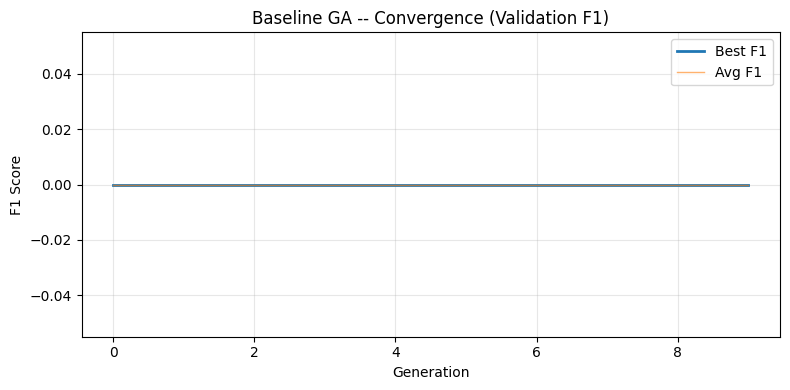

In [14]:
if RUN_BASELINE_GA:
    train_pred_base = apply_path(best_baseline_rule, X_train).astype(int)
    val_pred_base   = apply_path(best_baseline_rule, X_val).astype(int)
    test_pred_base  = apply_path(best_baseline_rule, X_test).astype(int)
    baseline_train_metrics = evaluate_metrics(y_train, train_pred_base)
    baseline_val_metrics   = evaluate_metrics(y_val,   val_pred_base)
    baseline_test_metrics  = evaluate_metrics(y_test,  test_pred_base)

    print("BASELINE GA -- Best Single Rule")
    print("=" * 60)
    print(pretty_path(best_baseline_rule))
    print(f"  Nodes: {len(best_baseline_rule)}")
    print(f"\n  Train -> Precision: {baseline_train_metrics['precision']:.4f}  "
          f"Recall: {baseline_train_metrics['recall']:.4f}  "
          f"F1: {baseline_train_metrics['f1']:.4f}  "
          f"Alert rate: {baseline_train_metrics['alert_rate']:.4f}")
    print(f"  Val  -> Precision: {baseline_val_metrics['precision']:.4f}  "
          f"Recall: {baseline_val_metrics['recall']:.4f}  "
          f"F1: {baseline_val_metrics['f1']:.4f}  "
          f"Alert rate: {baseline_val_metrics['alert_rate']:.4f}")
    print(f"  Test -> Precision: {baseline_test_metrics['precision']:.4f}  "
          f"Recall: {baseline_test_metrics['recall']:.4f}  "
          f"F1: {baseline_test_metrics['f1']:.4f}  "
          f"Alert rate: {baseline_test_metrics['alert_rate']:.4f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(baseline_history["gen"], baseline_history["best_f1"], label="Best F1", linewidth=2)
    ax.plot(baseline_history["gen"], baseline_history["avg_f1"],  label="Avg F1",  linewidth=1, alpha=0.6)
    ax.set_xlabel("Generation"); ax.set_ylabel("F1 Score")
    ax.set_title("Baseline GA -- Convergence (Validation F1)")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/baseline_convergence.png", dpi=150)
    plt.show()

---
## Section 6a: Baseline GA – Operator Grid Search

Sweeps all **7 crossover × 3 mutation × 5 selection = 105 combinations**  
using the same fitness function, population size, and generation count as the baseline GA.  
Results are saved to `baseline_grid_results.csv` and summarised with heatmaps.

In [15]:
# ============================================================
# SECTION 6a – BASELINE GA OPERATOR GRID SEARCH
# ============================================================
RUN_BASELINE_GRID = True   # Set False to skip

if RUN_BASELINE_GRID and RUN_BASELINE_GA:

    # ── Crossover variants ────────────────────────────────────────────
    def cx_one_point_custom(ind1, ind2):
        if len(ind1) > 1 and len(ind2) > 1:
            pt1 = random.randint(1, len(ind1) - 1)
            pt2 = random.randint(1, len(ind2) - 1)
            tail1, tail2 = copy.deepcopy(ind1[pt1:]), copy.deepcopy(ind2[pt2:])
            ind1[:] = list(ind1[:pt1]) + tail2
            ind2[:] = list(ind2[:pt2]) + tail1
            deduplicate_base(ind1); deduplicate_base(ind2)
        return ind1, ind2

    def cx_uniform_custom(ind1, ind2):
        all_conds = list(ind1) + list(ind2)
        random.shuffle(all_conds)
        seen, pool = set(), []
        for cond in all_conds:
            if cond[0] not in seen:
                pool.append(cond); seen.add(cond[0])
        mid = max(1, len(pool) // 2)
        ind1[:] = pool[:mid] if pool[:mid] else [random_condition_base()]
        ind2[:] = pool[mid:] if pool[mid:] else [random_condition_base()]
        return ind1, ind2

    def cx_deap_one_point(ind1, ind2):
        size = min(len(ind1), len(ind2))
        if size > 1:
            cxpt = random.randint(1, size - 1)
            ind1[cxpt:], ind2[cxpt:] = copy.deepcopy(ind2[cxpt:]), copy.deepcopy(ind1[cxpt:])
            deduplicate_base(ind1); deduplicate_base(ind2)
        return ind1, ind2

    def cx_deap_two_point(ind1, ind2):
        size = min(len(ind1), len(ind2))
        if size > 2:
            cxpt1 = random.randint(1, size - 2)
            cxpt2 = random.randint(cxpt1 + 1, size - 1)
            ind1[cxpt1:cxpt2], ind2[cxpt1:cxpt2] = (
                copy.deepcopy(ind2[cxpt1:cxpt2]),
                copy.deepcopy(ind1[cxpt1:cxpt2])
            )
            deduplicate_base(ind1); deduplicate_base(ind2)
        return ind1, ind2

    def cx_deap_uniform(ind1, ind2):
        size = min(len(ind1), len(ind2))
        for i in range(size):
            if random.random() < 0.5:
                ind1[i], ind2[i] = copy.deepcopy(ind2[i]), copy.deepcopy(ind1[i])
        deduplicate_base(ind1); deduplicate_base(ind2)
        return ind1, ind2

    def cx_deap_messy_one_point(ind1, ind2):
        cxpt1 = random.randint(0, len(ind1))
        cxpt2 = random.randint(0, len(ind2))
        new1 = list(ind1[:cxpt1]) + copy.deepcopy(list(ind2[cxpt2:]))
        new2 = list(ind2[:cxpt2]) + copy.deepcopy(list(ind1[cxpt1:]))
        ind1[:] = new1 if new1 else [random_condition_base()]
        ind2[:] = new2 if new2 else [random_condition_base()]
        deduplicate_base(ind1); deduplicate_base(ind2)
        return ind1, ind2

    CROSSOVER_OPS = {
        "SwapCX":          cx_base,
        "OnePointCustom":  cx_one_point_custom,
        "UniformCustom":   cx_uniform_custom,
        "cxOnePoint":      cx_deap_one_point,
        "cxTwoPoint":      cx_deap_two_point,
        "cxUniform":       cx_deap_uniform,
        "cxMessyOnePoint": cx_deap_messy_one_point,
    }

    # ── Mutation variants ─────────────────────────────────────────────
    def _make_mut_weighted(weights):
        ops = ["thr", "flip", "replace", "add", "drop"]
        def _mut(ind):
            op = random.choices(ops, weights=weights, k=1)[0]
            if op == "thr" and len(ind) > 0:
                i = random.randrange(len(ind))
                col, cur_op, _ = ind[i]
                ind[i] = (col, cur_op, float(random.choice(threshold_bank[col])))
            elif op == "flip" and len(ind) > 0:
                i = random.randrange(len(ind))
                col, cur_op, thr = ind[i]
                pool  = CATEGORICAL_OPS if col in CATEGORICAL_FEATURES else CONTINUOUS_OPS
                other = [o for o in pool if o != cur_op]
                ind[i] = (col, random.choice(other), thr)
            elif op == "replace" and len(ind) > 0:
                i    = random.randrange(len(ind))
                used = {c for c, _, _ in ind} - {ind[i][0]}
                ind[i] = random_condition_base(exclude=used)
            elif op == "add" and len(ind) < MAX_NODES_BASELINE:
                used = {c for c, _, _ in ind}
                ind.append(random_condition_base(exclude=used))
            elif op == "drop" and len(ind) > MIN_NODES_BASELINE:
                ind.pop(random.randrange(len(ind)))
            return (ind,)
        return _mut

    mut_uniform          = _make_mut_weighted([20, 20, 20, 20, 20])
    mut_threshold_biased = _make_mut_weighted([45, 30, 15,  5,  5])
    mut_structure_biased = _make_mut_weighted([10, 10, 20, 30, 30])

    MUTATION_OPS = {
        "UniformMut":         mut_uniform,
        "ThresholdBiasedMut": mut_threshold_biased,
        "StructureBiasedMut": mut_structure_biased,
    }

    # ── Selection variants ────────────────────────────────────────────
    def sel_roulette_safe(pop, k):
        fitnesses = [max(ind.fitness.values[0], 1e-9) for ind in pop]
        total = sum(fitnesses)
        probs = [f / total for f in fitnesses]
        return random.choices(pop, weights=probs, k=k)

    SELECTION_OPS = {
        "Tournament3": lambda pop, k: tools.selTournament(pop, k, tournsize=3),
        "Tournament5": lambda pop, k: tools.selTournament(pop, k, tournsize=5),
        "selBest":     lambda pop, k: tools.selBest(pop, k),
        "selRandom":   lambda pop, k: tools.selRandom(pop, k),
        "selRoulette": sel_roulette_safe,
    }

    total_combos = len(CROSSOVER_OPS) * len(MUTATION_OPS) * len(SELECTION_OPS)
    print(f"Grid search: {len(CROSSOVER_OPS)} CX x {len(MUTATION_OPS)} Mut x "
          f"{len(SELECTION_OPS)} Sel = {total_combos} combinations  (max {BASELINE_GENS} gens each)")

    # ── Helper GA runner with pluggable operators — returns (best, converged_at) ──
    def run_baseline_ga_ops(cx_fn, mut_fn, sel_fn,
                            pop_size=BASELINE_POP_SIZE,
                            generations=BASELINE_GENS,
                            patience=EARLY_STOP_PATIENCE):
        pop = base_tb.population(n=pop_size)
        hof = tools.HallOfFame(1)
        for ind in pop:
            ind.fitness.values = base_tb.evaluate(ind)
        hof.update(pop)
        no_improve   = 0
        best_so_far  = 0.0
        converged_at = generations - 1
        for g in range(generations):
            elite     = [base_tb.clone(hof[0])]
            offspring = list(map(base_tb.clone, sel_fn(pop, pop_size - 1)))
            for c1, c2 in zip(offspring[::2], offspring[1::2]):
                if random.random() < 0.4:
                    cx_fn(c1, c2)
                    del c1.fitness.values, c2.fitness.values
            for ind in offspring:
                if random.random() < 0.4:
                    mut_fn(ind)
                    del ind.fitness.values
            for ind in offspring:
                if not ind.fitness.valid:
                    ind.fitness.values = base_tb.evaluate(ind)
            pop[:] = elite + offspring
            hof.update(pop)
            best_f1 = hof[0].fitness.values[0]
            if best_f1 > best_so_far + 1e-6:
                best_so_far  = best_f1
                no_improve   = 0
            else:
                no_improve += 1
            if patience and no_improve >= patience:
                converged_at = g
                break
        return hof[0], converged_at

    # ── Run the grid ──────────────────────────────────────────────────────────
    import time as _time
    grid_results = []
    combo_idx    = 0
    t0_grid      = _time.time()

    for cx_name, cx_fn in CROSSOVER_OPS.items():
        for mut_name, mut_fn in MUTATION_OPS.items():
            for sel_name, sel_fn in SELECTION_OPS.items():
                combo_idx += 1
                t0 = _time.time()
                print(f"[{combo_idx:3d}/{total_combos}] CX={cx_name:<18} "
                      f"Mut={mut_name:<20} Sel={sel_name:<12}", end=" ", flush=True)
                try:
                    best_rule, converged_at_g = run_baseline_ga_ops(cx_fn, mut_fn, sel_fn)
                    train_pred = apply_path(best_rule, X_train).astype(int)
                    val_pred   = apply_path(best_rule, X_val).astype(int)
                    test_pred  = apply_path(best_rule, X_test).astype(int)
                    trm = evaluate_metrics(y_train, train_pred)
                    vm  = evaluate_metrics(y_val,   val_pred)
                    tm  = evaluate_metrics(y_test,  test_pred)
                    grid_results.append({
                        "cx": cx_name, "mut": mut_name, "sel": sel_name,
                        "max_budget":        BASELINE_GENS,
                        "converged_at":      converged_at_g,
                        "n_conditions":      len(best_rule),
                        "rule":              pretty_path(best_rule),
                        "train_f1":          trm["f1"],
                        "train_precision":   trm["precision"],
                        "train_recall":      trm["recall"],
                        "train_alert_rate":  trm["alert_rate"],
                        "val_f1":            vm["f1"],
                        "val_precision":     vm["precision"],
                        "val_recall":        vm["recall"],
                        "val_alert_rate":    vm["alert_rate"],
                        "test_f1":           tm["f1"],
                        "test_precision":    tm["precision"],
                        "test_recall":       tm["recall"],
                        "test_alert_rate":   tm["alert_rate"],
                        "error": None,
                    })
                    print(f"conv@{converged_at_g:3d}  val_F1={vm['f1']:.4f}  "
                          f"test_F1={tm['f1']:.4f}  ({_time.time()-t0:.1f}s)")
                except Exception as e:
                    print(f"ERROR: {e}")
                    grid_results.append({
                        "cx": cx_name, "mut": mut_name, "sel": sel_name,
                        "max_budget": BASELINE_GENS, "converged_at": None,
                        "n_conditions": None, "rule": None,
                        "train_f1": None, "train_precision": None,
                        "train_recall": None, "train_alert_rate": None,
                        "val_f1": None, "val_precision": None,
                        "val_recall": None, "val_alert_rate": None,
                        "test_f1": None, "test_precision": None,
                        "test_recall": None, "test_alert_rate": None,
                        "error": str(e),
                    })

    baseline_grid_df = pd.DataFrame(grid_results)
    print(f"\nGrid search done in {_time.time()-t0_grid:.1f}s — {len(baseline_grid_df)} combinations.")


Grid search: 7 CX x 3 Mut x 5 Sel = 105 combinations  (max 80 gens each)
[  1/105] CX=SwapCX             Mut=UniformMut           Sel=Tournament3  conv@  9  val_F1=0.0000  test_F1=0.0000  (0.0s)
[  2/105] CX=SwapCX             Mut=UniformMut           Sel=Tournament5  conv@  9  val_F1=0.0000  test_F1=0.0142  (0.0s)
[  3/105] CX=SwapCX             Mut=UniformMut           Sel=selBest      conv@  9  val_F1=0.0000  test_F1=0.0000  (0.0s)
[  4/105] CX=SwapCX             Mut=UniformMut           Sel=selRandom    conv@  9  val_F1=0.0000  test_F1=0.0000  (0.0s)
[  5/105] CX=SwapCX             Mut=UniformMut           Sel=selRoulette  conv@  9  val_F1=0.0000  test_F1=0.0000  (0.0s)
[  6/105] CX=SwapCX             Mut=ThresholdBiasedMut   Sel=Tournament3  conv@  9  val_F1=0.0000  test_F1=0.0000  (0.0s)
[  7/105] CX=SwapCX             Mut=ThresholdBiasedMut   Sel=Tournament5  conv@  9  val_F1=0.0000  test_F1=0.0000  (0.0s)
[  8/105] CX=SwapCX             Mut=ThresholdBiasedMut   Sel=selBest     

In [16]:
if RUN_BASELINE_GRID and RUN_BASELINE_GA:

    _df = baseline_grid_df.dropna(subset=["val_f1"]).copy()
    _df = _df.sort_values("val_f1", ascending=False).reset_index(drop=True)

    # -- Top 15 table --
    show_cols = ["cx", "mut", "sel",
                 "val_f1", "val_precision", "val_recall",
                 "test_f1", "test_precision", "test_recall"]
    print("Top 15 combinations by Validation F1")
    print("=" * 115)
    print(_df[show_cols].head(15).to_string(index=True, float_format="{:.4f}".format))

    best = _df.iloc[0]
    print("\n--- Best combination ---")
    print(f"  CX:  {best['cx']}")
    print(f"  Mut: {best['mut']}")
    print(f"  Sel: {best['sel']}")
    print(f"  Val  F1={best['val_f1']:.4f}  P={best['val_precision']:.4f}  R={best['val_recall']:.4f}")
    print(f"  Test F1={best['test_f1']:.4f}  P={best['test_precision']:.4f}  R={best['test_recall']:.4f}")


Top 15 combinations by Validation F1
            cx                 mut          sel  val_f1  val_precision  val_recall  test_f1  test_precision  test_recall
0       SwapCX          UniformMut  Tournament3  0.0000         0.0000      0.0000   0.0000          0.0000       0.0000
1   cxOnePoint  ThresholdBiasedMut    selRandom  0.0000         0.0000      0.0000   0.0000          0.0000       0.0000
2    cxUniform          UniformMut      selBest  0.0000         0.0000      0.0000   0.0000          0.0000       0.0000
3    cxUniform          UniformMut  Tournament5  0.0000         0.0000      0.0000   0.0000          0.0000       0.0000
4    cxUniform          UniformMut  Tournament3  0.0000         0.0000      0.0000   0.0000          0.0000       0.0000
5   cxTwoPoint  StructureBiasedMut  selRoulette  0.0000         0.0000      0.0000   0.0000          0.0000       0.0000
6   cxTwoPoint  StructureBiasedMut    selRandom  0.0000         0.0000      0.0000   0.0000          0.0000       0.

---
## Section 7: Coevolution GA — Rule Set Evolution (Algorithm v2)

Two co-evolving populations:

| Population | What evolves | Fitness |
|---|---|---|
| **Path pool** | Single AND-rules (<= `MAX_NODES_PER_PATH` conditions) | Standalone F1 on validation set |
| **Rule set pool** | OR-combinations of paths (<= `MAX_PATHS_PER_RS`) | F1 + diversity bonus - parsimony penalty |

Migration links the two populations every cycle:
- Best standalone paths are seeded into rule sets as building blocks
- Paths extracted from best rule sets are injected back into the path pool for further refinement

All logic is identical to the Kaggle pipeline. Conditions now reference real feature names
and the categorical encoding layer is already applied, so the GA operates on the same
integer arrays as before.


In [17]:
if not RUN_COEVOLUTION:
    print("Skipping Coevolution GA (RUN_COEVOLUTION = False)")
else:
    # -- Pre-compute fraud indices on val set ---------------------------------
    _fraud_idx_val    = np.where(np.asarray(y_val) == 1)[0]
    _fraud_mask_train = (np.asarray(y_train) == 1)
    _fraud_X_train    = X_train[_fraud_mask_train].reset_index(drop=True)

    # -- Condition / path / ruleset constructors ------------------------------
    def random_condition_co(exclude=None):
        exclude   = exclude or set()
        available = [f for f in FEATURES if f not in exclude]
        if not available:
            available = FEATURES
        col = random.choice(available)
        ops = CATEGORICAL_OPS if col in CATEGORICAL_FEATURES else CONTINUOUS_OPS
        return (col, random.choice(ops), float(random.choice(threshold_bank[col])))

    def deduplicate_path(path):
        seen, out = set(), []
        for cond in path:
            if cond[0] not in seen:
                out.append(cond)
                seen.add(cond[0])
        return out if out else [random_condition_co()]

    def random_path_co():
        k, used, path = random.randint(1, MAX_NODES_PER_PATH), set(), []
        for _ in range(k):
            cond = random_condition_co(exclude=used)
            path.append(cond)
            used.add(cond[0])
        return path

    def random_ruleset_co():
        n = random.randint(1, MAX_PATHS_PER_RS)
        return [random_path_co() for _ in range(n)]

    # -- DEAP creators --------------------------------------------------------
    if "PathFitness" not in creator.__dict__:
        creator.create("PathFitness", base.Fitness, weights=(1.0,))
    if "Path" not in creator.__dict__:
        creator.create("Path", list, fitness=creator.PathFitness)
    if "RulesetFitness" not in creator.__dict__:
        creator.create("RulesetFitness", base.Fitness, weights=(1.0,))
    if "Ruleset" not in creator.__dict__:
        creator.create("Ruleset", list, fitness=creator.RulesetFitness)

    # -- Fitness: path pool ---------------------------------------------------
    def eval_path_co(path):
        y_pred = apply_path(path, X_val).astype(int)
        tp = int((y_pred * np.asarray(y_val)).sum())
        if tp < MIN_TP_FITNESS:
            return (0.0,)
        return (f1_score(y_val, y_pred, zero_division=0),)

    # -- Fitness: rule set pool -----------------------------------------------
    # Multi-component: base_F1 + COVERAGE_LAMBDA*diversity - PARSIMONY_MU*parsimony
    # Diversity bonus rewards paths that catch fraud no other path catches.
    # Parsimony penalty discourages unnecessarily large rule sets.
    def eval_ruleset_co(ruleset):
        y_pred  = apply_ruleset(ruleset, X_val)
        base_f1 = f1_score(y_val, y_pred, zero_division=0)
        if len(ruleset) > 1 and len(_fraud_idx_val) > 0:
            fires = [apply_path(p, X_val)[_fraud_idx_val] for p in ruleset]
            unique_total = 0
            for i, mask_i in enumerate(fires):
                others = np.zeros(len(_fraud_idx_val), dtype=bool)
                for j, mask_j in enumerate(fires):
                    if j != i:
                        others |= mask_j
                unique_total += int((mask_i & ~others).sum())
            diversity = unique_total / (len(_fraud_idx_val) * len(ruleset))
        else:
            diversity = 0.0
        avg_nodes = np.mean([len(p) for p in ruleset]) if ruleset else 0
        parsimony = 0.5 * (len(ruleset) / MAX_PATHS_PER_RS) + \
                    0.5 * (avg_nodes / MAX_NODES_PER_PATH)
        score = base_f1 + COVERAGE_LAMBDA * diversity - PARSIMONY_MU * parsimony
        return (max(score, 0.0),)

    # -- Toolboxes ------------------------------------------------------------
    path_tb = base.Toolbox()
    path_tb.register("individual", tools.initIterate, creator.Path, random_path_co)
    path_tb.register("population", tools.initRepeat, list, path_tb.individual)
    path_tb.register("evaluate",   eval_path_co)
    path_tb.register("select",     tools.selTournament, tournsize=3)
    path_tb.register("clone",      copy.deepcopy)

    rs_tb = base.Toolbox()
    rs_tb.register("individual", tools.initIterate, creator.Ruleset, random_ruleset_co)
    rs_tb.register("population", tools.initRepeat, list, rs_tb.individual)
    rs_tb.register("evaluate",   eval_ruleset_co)
    rs_tb.register("select",     tools.selTournament, tournsize=3)
    rs_tb.register("clone",      copy.deepcopy)

    print("Coevolution toolboxes ready.")


Coevolution toolboxes ready.


In [18]:
if RUN_COEVOLUTION:
    # -- Genetic operators ----------------------------------------------------
    def mutate_path_co(path):
        op = random.choice(["thr", "flip", "replace", "add_node", "drop_node"])
        if op == "thr" and len(path) > 0:
            i = random.randrange(len(path))
            col, cur_op, _ = path[i]
            path[i] = (col, cur_op, float(random.choice(threshold_bank[col])))
        elif op == "flip" and len(path) > 0:
            i = random.randrange(len(path))
            col, cur_op, thr = path[i]
            pool  = CATEGORICAL_OPS if col in CATEGORICAL_FEATURES else CONTINUOUS_OPS
            other = [o for o in pool if o != cur_op]
            path[i] = (col, random.choice(other), thr)
        elif op == "replace" and len(path) > 0:
            i    = random.randrange(len(path))
            used = {c for c, _, _ in path} - {path[i][0]}
            path[i] = random_condition_co(exclude=used)
        elif op == "add_node" and len(path) < MAX_NODES_PER_PATH:
            used = {c for c, _, _ in path}
            path.append(random_condition_co(exclude=used))
        elif op == "drop_node" and len(path) > 1:
            path.pop(random.randrange(len(path)))
        return (path,)

    def cx_paths_co(p1, p2):
        if len(p1) > 0 and len(p2) > 0:
            i, j = random.randrange(len(p1)), random.randrange(len(p2))
            p1[i], p2[j] = copy.deepcopy(p2[j]), copy.deepcopy(p1[i])
            p1[:] = deduplicate_path(p1)
            p2[:] = deduplicate_path(p2)
        return p1, p2

    def mutate_ruleset_co(rs):
        op = random.choice(["add_path", "drop_path", "mutate_node"])
        if op == "add_path" and len(rs) < MAX_PATHS_PER_RS:
            rs.append(random_path_co())
        elif op == "drop_path" and len(rs) > 1:
            rs.pop(random.randrange(len(rs)))
        elif op == "mutate_node" and len(rs) > 0:
            i = random.randrange(len(rs))
            rs[i] = list(mutate_path_co(list(rs[i]))[0])
        return (rs,)

    def cx_rulesets_co(rs1, rs2):
        if len(rs1) > 0 and len(rs2) > 0:
            i, j = random.randrange(len(rs1)), random.randrange(len(rs2))
            rs1[i], rs2[j] = copy.deepcopy(rs2[j]), copy.deepcopy(rs1[i])
        return rs1, rs2

    path_tb.register("mutate", mutate_path_co)
    path_tb.register("mate",   cx_paths_co)
    rs_tb.register("mutate",   mutate_ruleset_co)
    rs_tb.register("mate",     cx_rulesets_co)

    # -- Evolution step (with elitism) ----------------------------------------
    def evo_step(pop, tb, cx_prob=0.5, mut_prob=0.4, n_elite=1):
        elite     = [tb.clone(e) for e in tools.selBest(pop, n_elite)]
        offspring = list(map(tb.clone, tb.select(pop, len(pop) - n_elite)))
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cx_prob:
                tb.mate(c1, c2)
                del c1.fitness.values, c2.fitness.values
        for ind in offspring:
            if random.random() < mut_prob:
                tb.mutate(ind)
                del ind.fitness.values
        for ind in offspring:
            if not ind.fitness.valid:
                ind.fitness.values = tb.evaluate(ind)
        return elite + offspring

    # -- Migration ------------------------------------------------------------
    def migrate_paths_to_rulesets(path_pop, rs_pop, n=N_MIGRATE):
        for path in tools.selBest(path_pop, n):
            target = random.choice(rs_pop)
            if len(target) < MAX_PATHS_PER_RS:
                target.append(copy.deepcopy(path))
            else:
                target[random.randrange(len(target))] = copy.deepcopy(path)
            del target.fitness.values

    def migrate_rulesets_to_paths(rs_pop, path_pop, n=3, cap=PATH_POP_CAP):
        for rs in tools.selBest(rs_pop, n):
            for raw_path in rs:
                p = creator.Path(copy.deepcopy(raw_path))
                p.fitness.values = path_tb.evaluate(p)
                path_pop.append(p)
        path_pop.sort(key=lambda x: x.fitness.values[0], reverse=True)
        del path_pop[cap:]

    print("Coevolution operators and migration ready.")


Coevolution operators and migration ready.


In [19]:
if RUN_COEVOLUTION:
    # -- Main coevolution loop ------------------------------------------------
    def run_coevolution(seed=RANDOM_SEED):
        random.seed(seed)
        np.random.seed(seed)
        path_pop = path_tb.population(n=PATH_POP_SIZE)
        rs_pop   = rs_tb.population(n=RULESET_POP_SIZE)
        for p in path_pop: p.fitness.values = path_tb.evaluate(p)
        for r in rs_pop:   r.fitness.values = rs_tb.evaluate(r)
        path_hof = tools.HallOfFame(HOF_SIZE)
        rs_hof   = tools.HallOfFame(HOF_SIZE)
        path_hof.update(path_pop)
        rs_hof.update(rs_pop)
        coevo_history = []
        print(f"  Seed={seed} | {PATH_POP_SIZE} paths, {RULESET_POP_SIZE} rule sets, {COEVO_CYCLES} cycles")
        for cycle in range(1, COEVO_CYCLES + 1):
            for _ in range(INNER_PATH_GENS):
                path_pop = evo_step(path_pop, path_tb)
            path_hof.update(path_pop)
            migrate_paths_to_rulesets(path_pop, rs_pop)
            for _ in range(INNER_RS_GENS):
                rs_pop = evo_step(rs_pop, rs_tb)
            rs_hof.update(rs_pop)
            migrate_rulesets_to_paths(rs_pop, path_pop)
            best_rs    = rs_hof[0]
            rs_pred    = apply_ruleset(best_rs, X_val)
            rs_true_f1 = f1_score(y_val, rs_pred, zero_division=0)
            alert      = float(rs_pred.sum()) / len(rs_pred)
            coevo_history.append({
                "cycle":              cycle,
                "best_path_f1":       path_hof[0].fitness.values[0],
                "best_rs_f1":         rs_true_f1,
                "best_rs_alert_rate": alert,
                "best_rs_n_paths":    len(best_rs),
            })
            if cycle % 2 == 0 or cycle == COEVO_CYCLES:
                print(f"  Cycle {cycle:2d}/{COEVO_CYCLES} | "
                      f"Path F1: {path_hof[0].fitness.values[0]:.4f} | "
                      f"RS F1: {rs_true_f1:.4f} | "
                      f"Paths: {len(best_rs)} | Alert: {alert:.4f}")
        return path_hof[0], rs_hof[0], pd.DataFrame(coevo_history), path_hof, rs_hof

    print("Running Coevolution GA (primary seed)...")
    best_path, best_ruleset, coevo_history, path_hof, rs_hof = run_coevolution(seed=RANDOM_SEED)
    print("\nCoevolution complete.")


Running Coevolution GA (primary seed)...
  Seed=42 | 60 paths, 40 rule sets, 80 cycles
  Cycle  2/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle  4/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle  6/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle  8/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle 10/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle 12/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle 14/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle 16/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle 18/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle 20/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle 22/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
  Cycle 24/80 | Path F1: 0.0000 | RS F1: 0.0000 | Paths: 13 | Alert: 0.4667
 

In [20]:

# ============================================================
# COEVOLUTION GA – 30-VARIANT PARAMETER SWEEP
# (coverage_lambda × parsimony_mu, 5×6 = 30 combos, max 2× cycles)
# ============================================================
if RUN_COEVOLUTION:
    import itertools

    _COEVO_SWEEP_MAX_CYCLES = 80                  # early-stop budget
    _COEVO_PATIENCE         = 6                   # early-stop patience

    def run_coevolution_variant(coverage_lambda, parsimony_mu,
                                max_cycles=_COEVO_SWEEP_MAX_CYCLES,
                                patience=_COEVO_PATIENCE,
                                seed=RANDOM_SEED):
        global COVERAGE_LAMBDA, PARSIMONY_MU
        old_lambda, old_mu = COVERAGE_LAMBDA, PARSIMONY_MU
        COVERAGE_LAMBDA = coverage_lambda
        PARSIMONY_MU    = parsimony_mu
        try:
            random.seed(seed)
            np.random.seed(seed)
            path_pop = path_tb.population(n=PATH_POP_SIZE)
            rs_pop   = rs_tb.population(n=RULESET_POP_SIZE)
            for p in path_pop: p.fitness.values = path_tb.evaluate(p)
            for r in rs_pop:   r.fitness.values = rs_tb.evaluate(r)
            _path_hof = tools.HallOfFame(HOF_SIZE)
            _rs_hof   = tools.HallOfFame(HOF_SIZE)
            _path_hof.update(path_pop)
            _rs_hof.update(rs_pop)

            best_f1_so_far = -1.0
            no_improv      = 0
            converged_at   = max_cycles

            for cycle in range(1, max_cycles + 1):
                for _ in range(INNER_PATH_GENS):
                    path_pop = evo_step(path_pop, path_tb)
                _path_hof.update(path_pop)
                migrate_paths_to_rulesets(path_pop, rs_pop)
                for _ in range(INNER_RS_GENS):
                    rs_pop = evo_step(rs_pop, rs_tb)
                _rs_hof.update(rs_pop)
                migrate_rulesets_to_paths(rs_pop, path_pop)

                rs_pred    = apply_ruleset(_rs_hof[0], X_val)
                rs_true_f1 = f1_score(y_val, rs_pred, zero_division=0)

                if rs_true_f1 > best_f1_so_far + 1e-6:
                    best_f1_so_far = rs_true_f1
                    no_improv      = 0
                else:
                    no_improv += 1

                if no_improv >= patience:
                    converged_at = cycle
                    break
            else:
                converged_at = max_cycles

            best_rs    = _rs_hof[0]
            train_pred = apply_ruleset(best_rs, X_train)
            val_pred   = apply_ruleset(best_rs, X_val)
            test_pred  = apply_ruleset(best_rs, X_test)
            trm = evaluate_metrics(y_train, train_pred)
            vm  = evaluate_metrics(y_val,   val_pred)
            tm  = evaluate_metrics(y_test,  test_pred)

            return {
                "model":            "Coevolution GA",
                "variant":          f"lam{coverage_lambda}_mu{parsimony_mu}",
                "coverage_lambda":  coverage_lambda,
                "parsimony_mu":     parsimony_mu,
                "pop_size":         None,
                "cx_prob":          None,
                "max_budget":       max_cycles,
                "converged_at":     converged_at,
                "n_paths":          len(best_rs),
                "total_conditions": sum(len(p) for p in best_rs),
                "train_precision":  trm["precision"],
                "train_recall":     trm["recall"],
                "train_f1":         trm["f1"],
                "train_alert_rate": trm["alert_rate"],
                "val_precision":    vm["precision"],
                "val_recall":       vm["recall"],
                "val_f1":           vm["f1"],
                "val_alert_rate":   vm["alert_rate"],
                "test_precision":   tm["precision"],
                "test_recall":      tm["recall"],
                "test_f1":          tm["f1"],
                "test_alert_rate":  tm["alert_rate"],
                "best_rule_str":    pretty_ruleset(best_rs),
            }
        finally:
            COVERAGE_LAMBDA = old_lambda
            PARSIMONY_MU    = old_mu

    _coevo_lambdas = [0.01, 0.02, 0.05, 0.10, 0.20]
    _coevo_mus     = [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]
    _coevo_grid    = list(itertools.product(_coevo_lambdas, _coevo_mus))

    coevo_sweep_results = []
    print(f"Coevolution GA sweep: {len(_coevo_grid)} variants "
          f"(max {_COEVO_SWEEP_MAX_CYCLES} cycles, patience={_COEVO_PATIENCE})")
    for i, (lam, mu) in enumerate(_coevo_grid, 1):
        print(f"  [{i:2d}/{len(_coevo_grid)}] lambda={lam}, mu={mu}", end="  ")
        row = run_coevolution_variant(lam, mu)
        coevo_sweep_results.append(row)
        print(f"converged@{row['converged_at']:2d}  val_f1={row['val_f1']:.4f}  test_f1={row['test_f1']:.4f}")

    df_coevo_sweep = pd.DataFrame(coevo_sweep_results)
    print(f"\nCoevolution sweep done. {len(df_coevo_sweep)} variants.")


Coevolution GA sweep: 30 variants (max 80 cycles, patience=6)
  [ 1/30] lambda=0.01, mu=0.005  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [ 2/30] lambda=0.01, mu=0.01  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [ 3/30] lambda=0.01, mu=0.02  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [ 4/30] lambda=0.01, mu=0.05  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [ 5/30] lambda=0.01, mu=0.1  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [ 6/30] lambda=0.01, mu=0.2  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [ 7/30] lambda=0.02, mu=0.005  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [ 8/30] lambda=0.02, mu=0.01  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [ 9/30] lambda=0.02, mu=0.02  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [10/30] lambda=0.02, mu=0.05  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [11/30] lambda=0.02, mu=0.1  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [12/30] lambda=0.02, mu=0.2  converged@ 7  val_f1=0.0000  test_f1=0.0117
  [13/30] lambda=0.05, mu=0.

COEVOLUTION GA -- Best Rule Set
  Rule 1: Transactions_Last_24h > 4.0000  AND  Device_Risk_Score_bin >= 8  AND  IP_Risk_Score >= 37.4000  AND  Time_Since_Last_Transaction <= 29.9600  AND  Email_Domain_Age_Days < 1887.0000
  Rule 2: Transactions_Last_7d >= 11.0000  AND  Email_Domain_Age_Days < 144.0000  AND  Days_Since_Last_Address_Change <= 48.0000  AND  Transaction_Hour <= 10.0000
  Rule 3: Transactions_Last_24h >= 4.0000  AND  Session_Duration <= 93.8000  AND  Geo_Location_Risk >= 32.6000  AND  Credit_Limit_Utilization >= 0.1190  AND  Time_Since_Last_Transaction < 4.2490
  Rule 4: Credit_Limit_Utilization > 0.7050  AND  Geo_Location_Risk >= 42.1000  AND  IP_Risk_Score >= 28.1000  AND  Days_Since_Last_Address_Change < 538.0000
  Rule 5: Days_Since_Last_Address_Change < 48.0000  AND  Account_Age_Days <= 932.0000  AND  Failed_Login_Count >= 2.0000  AND  Transactions_Last_24h > 3.0000  AND  Session_Duration <= 648.4000

  Paths: 5 | Nodes per path: [5, 4, 5, 4, 5]

  Train -> Precision: 

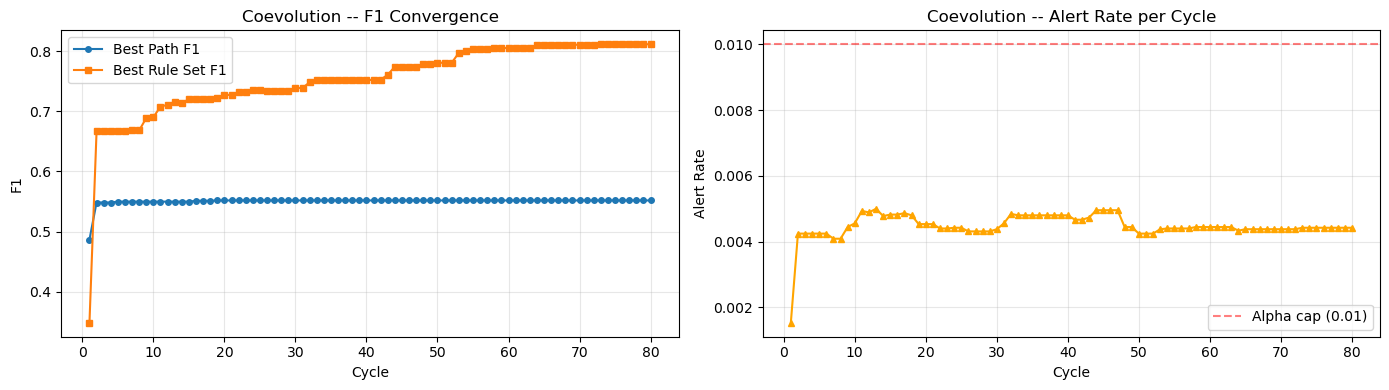

In [ ]:
if RUN_COEVOLUTION:
    train_pred_co = apply_ruleset(best_ruleset, X_train)
    val_pred_co   = apply_ruleset(best_ruleset, X_val)
    test_pred_co  = apply_ruleset(best_ruleset, X_test)
    co_train_metrics = evaluate_metrics(y_train, train_pred_co)
    co_val_metrics   = evaluate_metrics(y_val,   val_pred_co)
    co_test_metrics  = evaluate_metrics(y_test,  test_pred_co)

    print("COEVOLUTION GA -- Best Rule Set")
    print("=" * 70)
    print(pretty_ruleset(best_ruleset))
    print(f"\n  Paths: {len(best_ruleset)} | Nodes per path: {[len(p) for p in best_ruleset]}")
    print(f"\n  Train -> Precision: {co_train_metrics['precision']:.4f}  "
          f"Recall: {co_train_metrics['recall']:.4f}  "
          f"F1: {co_train_metrics['f1']:.4f}  "
          f"Alert: {co_train_metrics['alert_rate']:.4f}")
    print(f"  Val  -> Precision: {co_val_metrics['precision']:.4f}  "
          f"Recall: {co_val_metrics['recall']:.4f}  "
          f"F1: {co_val_metrics['f1']:.4f}  "
          f"Alert: {co_val_metrics['alert_rate']:.4f}")
    print(f"  Test -> Precision: {co_test_metrics['precision']:.4f}  "
          f"Recall: {co_test_metrics['recall']:.4f}  "
          f"F1: {co_test_metrics['f1']:.4f}  "
          f"Alert: {co_test_metrics['alert_rate']:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(coevo_history["cycle"], coevo_history["best_path_f1"], label="Best Path F1", marker="o", markersize=4)
    axes[0].plot(coevo_history["cycle"], coevo_history["best_rs_f1"], label="Best Rule Set F1", marker="s", markersize=4)
    axes[0].set_xlabel("Cycle"); axes[0].set_ylabel("F1")
    axes[0].set_title("Coevolution -- F1 Convergence")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(coevo_history["cycle"], coevo_history["best_rs_alert_rate"], color="orange", marker="^", markersize=4)
    axes[1].axhline(ALPHA, color="red", linestyle="--", alpha=0.5, label=f"Alpha cap ({ALPHA})")
    axes[1].set_xlabel("Cycle"); axes[1].set_ylabel("Alert Rate")
    axes[1].set_title("Coevolution -- Alert Rate per Cycle")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/coevo_convergence.png", dpi=150)
    plt.show()

---
## Section 8: Pareto Front & Operating Points

| Point | Objective | Alert rate cap |
|---|---|---|
| **Conservative** | Max precision | <= 0.05% |
| **Balanced** | Max F2 (recall-weighted) | <= 0.20% |
| **Aggressive** | Max recall | <= 1.00%, precision >= 0.10 |


In [ ]:
if RUN_COEVOLUTION:
    pareto_rows = []
    for rs in list(rs_hof):
        vp = apply_ruleset(rs, X_val)
        m  = evaluate_metrics(y_val, vp)
        rule_str = pretty_ruleset(rs)
        pareto_rows.append({
            "precision":        m["precision"],
            "recall":           m["recall"],
            "f1":               m["f1"],
            "alert_rate":       m["alert_rate"],
            "n_rules":          len(rs),
            "total_conditions": sum(len(p) for p in rs),
            "rule_set_string":  rule_str,
            "ruleset_obj":      rs,
        })

    pareto_df = pd.DataFrame(pareto_rows)
    pareto_df.to_csv(f"{OUTPUT_DIR}/pareto_front.csv", index=False)

    def select_operating_points(df):
        ops = {}
        cand = df[df["alert_rate"] <= 0.0005]
        if not cand.empty:
            ops["conservative"] = cand.loc[cand["precision"].idxmax()]
        cand = df[df["alert_rate"] <= 0.002]
        if not cand.empty:
            f2 = (5 * cand["precision"] * cand["recall"]) / \
                 (4 * cand["precision"] + cand["recall"] + 1e-12)
            ops["balanced"] = cand.loc[f2.idxmax()]
        cand = df[(df["alert_rate"] <= ALPHA) & (df["precision"] >= 0.10)]
        if not cand.empty:
            ops["aggressive"] = cand.loc[cand["recall"].idxmax()]
        return ops

    operating_points = select_operating_points(pareto_df)

    print("Operating Points (Validation Set):")
    print("=" * 70)
    for name, row in operating_points.items():
        print(f"\n[{name.upper()}]")
        print(f"  Precision: {row['precision']:.4f} | Recall: {row['recall']:.4f} | "
              f"F1: {row['f1']:.4f} | Alert rate: {row['alert_rate']:.4f}")
        print(f"  Paths: {int(row['n_rules'])} | Total conditions: {int(row['total_conditions'])}")
        print(f"  Rule set:\n{row['rule_set_string']}")


Operating Points (Validation Set):

[AGGRESSIVE]
  Precision: 0.9095 | Recall: 0.7328 | F1: 0.8117 | Alert rate: 0.0044
  Paths: 5 | Total conditions: 23
  Rule set:
  Rule 1: Transactions_Last_24h > 4.0000  AND  Device_Risk_Score_bin >= 8  AND  IP_Risk_Score >= 37.4000  AND  Time_Since_Last_Transaction <= 29.9600  AND  Email_Domain_Age_Days < 1887.0000
  Rule 2: Transactions_Last_7d >= 11.0000  AND  Email_Domain_Age_Days < 144.0000  AND  Days_Since_Last_Address_Change <= 48.0000  AND  Transaction_Hour <= 10.0000
  Rule 3: Transactions_Last_24h >= 4.0000  AND  Session_Duration <= 93.8000  AND  Geo_Location_Risk >= 32.6000  AND  Credit_Limit_Utilization >= 0.1190  AND  Time_Since_Last_Transaction < 4.2490
  Rule 4: Credit_Limit_Utilization > 0.7050  AND  Geo_Location_Risk >= 42.1000  AND  IP_Risk_Score >= 28.1000  AND  Days_Since_Last_Address_Change < 538.0000
  Rule 5: Days_Since_Last_Address_Change < 48.0000  AND  Account_Age_Days <= 932.0000  AND  Failed_Login_Count >= 2.0000  AND  T

In [ ]:
if RUN_COEVOLUTION:
    print("Operating Points -- TEST Set Evaluation")
    print("=" * 70)
    test_op_results = {}
    for name, row in operating_points.items():
        rs = row["ruleset_obj"]
        tp = apply_ruleset(rs, X_test)
        m  = evaluate_metrics(y_test, tp)
        test_op_results[name] = m
        print(f"\n[{name.upper()}]")
        print(f"  Precision: {m['precision']:.4f} | Recall: {m['recall']:.4f} | "
              f"F1: {m['f1']:.4f} | Alert rate: {m['alert_rate']:.4f}")
        print(f"  TP={m['TP']}  FP={m['FP']}  FN={m['FN']}  TN={m['TN']}")

    with open(f"{OUTPUT_DIR}/selected_operating_points.json", "w") as f:
        json.dump({
            k: {"val":  {"precision": float(operating_points[k]["precision"]),
                         "recall":    float(operating_points[k]["recall"]),
                         "f1":        float(operating_points[k]["f1"]),
                         "alert_rate":float(operating_points[k]["alert_rate"])},
                "test": {kk: float(vv) for kk, vv in m.items() if kk not in ["TP","FP","FN","TN"]},
                "rule_set_string": operating_points[k]["rule_set_string"]}
            for k, m in test_op_results.items()
        }, f, indent=2)
    print(f"\nSaved to {OUTPUT_DIR}/selected_operating_points.json")


Operating Points -- TEST Set Evaluation

[AGGRESSIVE]
  Precision: 0.7722 | Recall: 0.6096 | F1: 0.6814 | Alert rate: 0.0040
  TP=139  FP=41  FN=89  TN=44731

Saved to C:/Users/schyu/Downloads/OneDrive_1_3-10-2026/outputs/selected_operating_points.json


---
## Section 7a: NSGA-II Multi-Objective Rule Set Evolution

Direct multi-objective alternative to Coevolution.

| Property | Coevolution GA | NSGA-II |
|---|---|---|
| Individual | OR-of-AND ruleset | OR-of-AND ruleset (same) |
| Fitness | Scalarised F1 + diversity − parsimony | (Precision, Recall) separately |
| Selection | Tournament(3) | Binary tournament + crowding distance |
| Output | Single best ruleset | Full Pareto front of rulesets |

The NSGA-II front is then filtered with the same `select_operating_points` logic
(conservative / balanced / aggressive) to produce directly comparable operating points.

In [ ]:
# ============================================================
# SECTION 7a – NSGA-II MULTI-OBJECTIVE RULE SET EVOLUTION
# ============================================================
if RUN_NSGA2 and RUN_COEVOLUTION:

    # ── DEAP types (2-objective: maximise precision AND recall) ────────────
    if "FitnessNSGA2" not in creator.__dict__:
        creator.create("FitnessNSGA2", base.Fitness, weights=(1.0, 1.0))
    if "RulesetNSGA2" not in creator.__dict__:
        creator.create("RulesetNSGA2", list, fitness=creator.FitnessNSGA2)

    # ── Fitness: (precision, recall) on validation set ─────────────────
    def eval_ruleset_nsga2(ruleset):
        y_pred = apply_ruleset(ruleset, X_val)
        tp = int((y_pred * np.asarray(y_val)).sum())
        if tp < MIN_TP_FITNESS:
            return (0.0, 0.0)
        m = evaluate_metrics(y_val, y_pred)
        return (m["precision"], m["recall"])

    # ── Toolbox (reuses coevo constructors and operators) ───────────────
    nsga2_tb = base.Toolbox()
    nsga2_tb.register("individual", tools.initIterate,
                      creator.RulesetNSGA2, random_ruleset_co)
    nsga2_tb.register("population", tools.initRepeat, list, nsga2_tb.individual)
    nsga2_tb.register("evaluate",   eval_ruleset_nsga2)
    nsga2_tb.register("mate",       cx_rulesets_co)
    nsga2_tb.register("mutate",     mutate_ruleset_co)
    nsga2_tb.register("clone",      copy.deepcopy)

    # ── Hypervolume proxy: area under P–R step curve (reference = origin) ────
    def _hv2d(front):
        pts = sorted(
            [(ind.fitness.values[1], ind.fitness.values[0]) for ind in front]
        )  # sort by recall ascending
        hv, prev_r = 0.0, 0.0
        for r, p in pts:
            hv += p * (r - prev_r)
            prev_r = r
        return hv

    # ── NSGA-II main loop ────────────────────────────────────────────────
    def run_nsga2(seed=RANDOM_SEED, pop_size=NSGA2_POP_SIZE, generations=NSGA2_GENS):
        random.seed(seed); np.random.seed(seed)
        pop = nsga2_tb.population(n=pop_size)
        for ind in pop:
            ind.fitness.values = nsga2_tb.evaluate(ind)
        # Initial non-dominated sort + crowding distance assignment
        pop = tools.selNSGA2(pop, pop_size)
        history = []
        print(f"  NSGA-II: pop={pop_size}, gens={generations}, seed={seed}")
        for g in range(generations):
            # Variation: crowding-distance binary tournament -> crossover -> mutation
            mating_pool = tools.selTournamentDCD(pop, pop_size)
            offspring   = [nsga2_tb.clone(ind) for ind in mating_pool]
            for c1, c2 in zip(offspring[::2], offspring[1::2]):
                if random.random() < 0.5:
                    nsga2_tb.mate(c1, c2)
                    del c1.fitness.values
                    del c2.fitness.values
            for ind in offspring:
                if random.random() < 0.4:
                    nsga2_tb.mutate(ind)
                    del ind.fitness.values
            for ind in offspring:
                if not ind.fitness.valid:
                    ind.fitness.values = nsga2_tb.evaluate(ind)
            # Survivor selection: NSGA-II on combined parent + offspring pool
            pop = tools.selNSGA2(pop + offspring, pop_size)
            front0   = tools.sortNondominated(pop, pop_size, first_front_only=True)[0]
            hv       = _hv2d(front0)
            best_p   = max(ind.fitness.values[0] for ind in front0)
            best_r   = max(ind.fitness.values[1] for ind in front0)
            best_f1  = max(
                2 * ind.fitness.values[0] * ind.fitness.values[1]
                / (ind.fitness.values[0] + ind.fitness.values[1] + 1e-12)
                for ind in front0
            )
            history.append({
                "gen": g, "front_size": len(front0),
                "best_precision": best_p, "best_recall": best_r,
                "best_f1": best_f1, "hypervolume": hv,
            })
            if g % 5 == 0 or g == generations - 1:
                print(f"  Gen {g:3d} | Front: {len(front0):3d} | "
                      f"P={best_p:.4f}  R={best_r:.4f}  F1={best_f1:.4f}  HV={hv:.4f}")
        final_front = tools.sortNondominated(pop, pop_size, first_front_only=True)[0]
        return final_front, pd.DataFrame(history)

    print("Running NSGA-II...")
    nsga2_front, nsga2_history = run_nsga2()
    print(f"\nNSGA-II complete. Final Pareto front size: {len(nsga2_front)}")


Running NSGA-II...
  NSGA-II: pop=100, gens=80, seed=42
  Gen   0 | Front:  11 | P=0.0913  R=1.0000  F1=0.0835  HV=0.0290
  Gen   5 | Front:  35 | P=0.6800  R=1.0000  F1=0.2810  HV=0.1436
  Gen  10 | Front:  51 | P=0.8095  R=1.0000  F1=0.3684  HV=0.2115
  Gen  15 | Front:  90 | P=0.8095  R=1.0000  F1=0.4454  HV=0.2941
  Gen  20 | Front:  86 | P=0.8182  R=1.0000  F1=0.4672  HV=0.3361
  Gen  25 | Front:  94 | P=0.8400  R=1.0000  F1=0.4711  HV=0.3707
  Gen  30 | Front: 100 | P=0.8889  R=1.0000  F1=0.5035  HV=0.4106
  Gen  35 | Front: 100 | P=0.8889  R=1.0000  F1=0.5059  HV=0.4321
  Gen  40 | Front: 100 | P=0.9429  R=1.0000  F1=0.5059  HV=0.4751
  Gen  45 | Front: 100 | P=0.9429  R=1.0000  F1=0.5217  HV=0.4992
  Gen  50 | Front: 100 | P=0.9459  R=1.0000  F1=0.5746  HV=0.5224
  Gen  55 | Front: 100 | P=1.0000  R=1.0000  F1=0.5765  HV=0.5386
  Gen  60 | Front: 100 | P=1.0000  R=1.0000  F1=0.6062  HV=0.5566
  Gen  65 | Front: 100 | P=1.0000  R=1.0000  F1=0.6115  HV=0.5845
  Gen  70 | Front: 1

In [ ]:

# ============================================================
# NSGA-II – 30-VARIANT PARAMETER SWEEP
# (pop_size × cx_prob, 5×6 = 30 combos, max 2× generations)
# ============================================================
if RUN_NSGA2 and RUN_COEVOLUTION:
    import itertools

    _NSGA2_SWEEP_MAX_GENS = 80                # early-stop budget
    _NSGA2_PATIENCE       = 8                 # early-stop patience on hypervolume

    def run_nsga2_variant(pop_size, cx_prob,
                          max_gens=_NSGA2_SWEEP_MAX_GENS,
                          patience=_NSGA2_PATIENCE,
                          seed=RANDOM_SEED):
        pop_size = ((pop_size + 3) // 4) * 4  # selTournamentDCD requires pop_size % 4 == 0
        random.seed(seed)
        np.random.seed(seed)
        pop = nsga2_tb.population(n=pop_size)
        for ind in pop:
            ind.fitness.values = nsga2_tb.evaluate(ind)
        pop = tools.selNSGA2(pop, pop_size)

        best_hv_so_far = -1.0
        no_improv      = 0
        converged_at   = max_gens

        for g in range(max_gens):
            mating_pool = tools.selTournamentDCD(pop, pop_size)
            offspring   = [nsga2_tb.clone(ind) for ind in mating_pool]
            for c1, c2 in zip(offspring[::2], offspring[1::2]):
                if random.random() < cx_prob:
                    nsga2_tb.mate(c1, c2)
                    del c1.fitness.values
                    del c2.fitness.values
            for ind in offspring:
                if random.random() < 0.4:
                    nsga2_tb.mutate(ind)
                    del ind.fitness.values
            for ind in offspring:
                if not ind.fitness.valid:
                    ind.fitness.values = nsga2_tb.evaluate(ind)
            pop    = tools.selNSGA2(pop + offspring, pop_size)
            front0 = tools.sortNondominated(pop, pop_size, first_front_only=True)[0]
            hv     = _hv2d(front0)

            if hv > best_hv_so_far + 1e-6:
                best_hv_so_far = hv
                no_improv      = 0
            else:
                no_improv += 1

            if no_improv >= patience:
                converged_at = g + 1
                break
        else:
            converged_at = max_gens

        # Pick best-F1 individual from final Pareto front
        final_front = tools.sortNondominated(pop, pop_size, first_front_only=True)[0]
        best_ind = max(
            final_front,
            key=lambda ind: 2 * ind.fitness.values[0] * ind.fitness.values[1]
                            / (ind.fitness.values[0] + ind.fitness.values[1] + 1e-12)
        )

        train_pred = apply_ruleset(best_ind, X_train)
        val_pred   = apply_ruleset(best_ind, X_val)
        test_pred  = apply_ruleset(best_ind, X_test)
        trm = evaluate_metrics(y_train, train_pred)
        vm  = evaluate_metrics(y_val,   val_pred)
        tm  = evaluate_metrics(y_test,  test_pred)

        return {
            "model":            "NSGA-II",
            "variant":          f"pop{pop_size}_cx{cx_prob}",
            "coverage_lambda":  None,
            "parsimony_mu":     None,
            "pop_size":         pop_size,
            "cx_prob":          cx_prob,
            "max_budget":       max_gens,
            "converged_at":     converged_at,
            "n_paths":          len(best_ind),
            "total_conditions": sum(len(p) for p in best_ind),
            "train_precision":  trm["precision"],
            "train_recall":     trm["recall"],
            "train_f1":         trm["f1"],
            "train_alert_rate": trm["alert_rate"],
            "val_precision":    vm["precision"],
            "val_recall":       vm["recall"],
            "val_f1":           vm["f1"],
            "val_alert_rate":   vm["alert_rate"],
            "test_precision":   tm["precision"],
            "test_recall":      tm["recall"],
            "test_f1":          tm["f1"],
            "test_alert_rate":  tm["alert_rate"],
            "best_rule_str":    pretty_ruleset(best_ind),
        }

    _nsga2_pops = [50, 75, 100, 150, 200]
    _nsga2_cxs  = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    _nsga2_grid = list(itertools.product(_nsga2_pops, _nsga2_cxs))

    nsga2_sweep_results = []
    print(f"NSGA-II sweep: {len(_nsga2_grid)} variants "
          f"(max {_NSGA2_SWEEP_MAX_GENS} gens, patience={_NSGA2_PATIENCE})")
    for i, (ps, cx) in enumerate(_nsga2_grid, 1):
        print(f"  [{i:2d}/{len(_nsga2_grid)}] pop={ps}, cx_prob={cx}", end="  ")
        row = run_nsga2_variant(ps, cx)
        nsga2_sweep_results.append(row)
        print(f"converged@{row['converged_at']:3d}  val_f1={row['val_f1']:.4f}  test_f1={row['test_f1']:.4f}")

    df_nsga2_sweep = pd.DataFrame(nsga2_sweep_results)
    print(f"\nNSGA-II sweep done. {len(df_nsga2_sweep)} variants.")


NSGA-II sweep: 30 variants (max 80 gens, patience=8)
  [ 1/30] pop=50, cx_prob=0.3  converged@ 80  val_f1=0.5296  test_f1=0.5126
  [ 2/30] pop=50, cx_prob=0.4  converged@ 80  val_f1=0.6498  test_f1=0.5722
  [ 3/30] pop=50, cx_prob=0.5  converged@ 80  val_f1=0.5354  test_f1=0.5035
  [ 4/30] pop=50, cx_prob=0.6  converged@ 80  val_f1=0.6478  test_f1=0.6111
  [ 5/30] pop=50, cx_prob=0.7  converged@ 80  val_f1=0.6339  test_f1=0.6204
  [ 6/30] pop=50, cx_prob=0.8  converged@ 80  val_f1=0.6127  test_f1=0.6432
  [ 7/30] pop=75, cx_prob=0.3  converged@ 80  val_f1=0.5985  test_f1=0.5508
  [ 8/30] pop=75, cx_prob=0.4  converged@ 80  val_f1=0.6250  test_f1=0.5764
  [ 9/30] pop=75, cx_prob=0.5  converged@ 80  val_f1=0.6736  test_f1=0.6051
  [10/30] pop=75, cx_prob=0.6  converged@ 80  val_f1=0.6459  test_f1=0.5500
  [11/30] pop=75, cx_prob=0.7  converged@ 80  val_f1=0.5819  test_f1=0.5463
  [12/30] pop=75, cx_prob=0.8  converged@ 80  val_f1=0.6573  test_f1=0.5880
  [13/30] pop=100, cx_prob=0.3  con

NSGA-II Operating Points (Train → Val → Test):

[CONSERVATIVE]
  Train P=0.6986  R=0.0498  F1=0.0929  Alert=0.0003
  Val   P=1.0000  R=0.0891  F1=0.1636  Alert=0.0005
  Test  P=0.8333  R=0.0877  F1=0.1587  Alert=0.0005
  Paths: 4  |  Conditions: 29

[BALANCED]
  Train P=0.8827  R=0.2644  F1=0.4069  Alert=0.0015
  Val   P=0.9610  R=0.2996  F1=0.4568  Alert=0.0017
  Test  P=0.9265  R=0.2763  F1=0.4257  Alert=0.0015
  Paths: 4  |  Conditions: 21

[AGGRESSIVE]
  Train P=0.3633  R=0.6576  F1=0.4681  Alert=0.0088
  Val   P=0.3939  R=0.6761  F1=0.4978  Alert=0.0094
  Test  P=0.3936  R=0.6974  F1=0.5032  Alert=0.0090
  Paths: 5  |  Conditions: 21


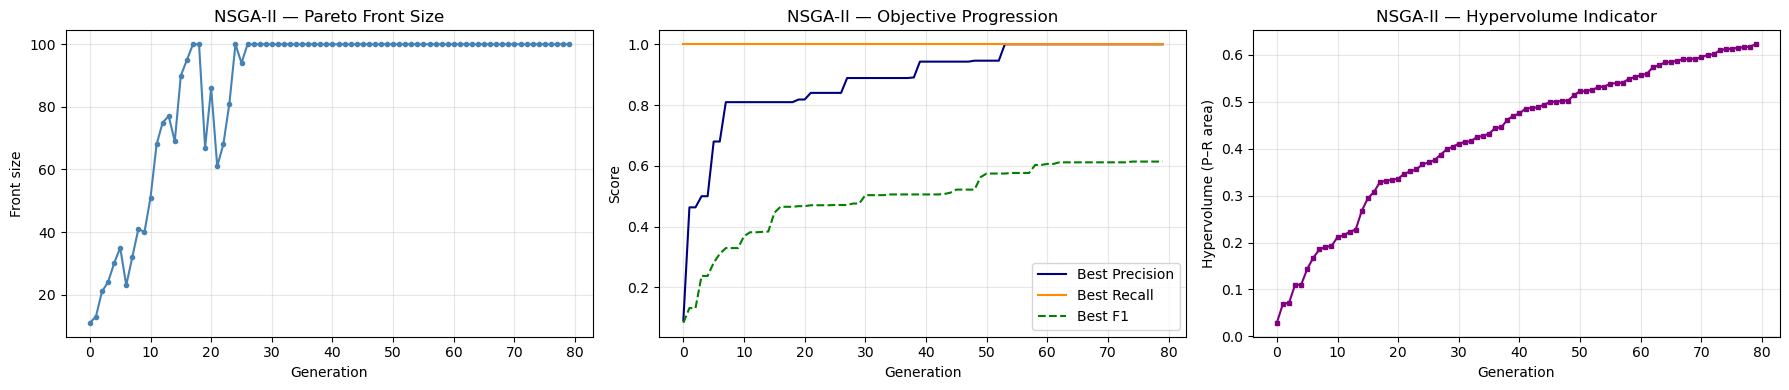

Saved to C:/Users/schyu/Downloads/OneDrive_1_3-10-2026/outputs/nsga2_convergence.png


In [ ]:
if RUN_NSGA2 and RUN_COEVOLUTION:

    # ── Evaluate every Pareto-front member on train + val + test ─────────────────
    nsga2_rows = []
    for ind in nsga2_front:
        trp = apply_ruleset(ind, X_train)
        vp  = apply_ruleset(ind, X_val)
        tp  = apply_ruleset(ind, X_test)
        trm = evaluate_metrics(y_train, trp)
        vm  = evaluate_metrics(y_val,   vp)
        tm  = evaluate_metrics(y_test,  tp)
        nsga2_rows.append({
            "train_precision":  trm["precision"],
            "train_recall":     trm["recall"],
            "train_f1":         trm["f1"],
            "train_alert_rate": trm["alert_rate"],
            "precision":        vm["precision"],
            "recall":           vm["recall"],
            "f1":               vm["f1"],
            "alert_rate":       vm["alert_rate"],
            "test_precision":   tm["precision"],
            "test_recall":      tm["recall"],
            "test_f1":          tm["f1"],
            "test_alert_rate":  tm["alert_rate"],
            "n_rules":          len(ind),
            "total_conditions": sum(len(p) for p in ind),
            "rule_set_string":  pretty_ruleset(ind),
            "ruleset_obj":      ind,
        })
    nsga2_pareto_df = pd.DataFrame(nsga2_rows)
    nsga2_pareto_df.drop(columns=["ruleset_obj"]).to_csv(
        f"{OUTPUT_DIR}/nsga2_pareto_front.csv", index=False)

    # ── Operating points from NSGA-II front ────────────────────────────
    nsga2_ops          = select_operating_points(nsga2_pareto_df)
    nsga2_test_op_res  = {}
    nsga2_train_op_res = {}
    print("NSGA-II Operating Points (Train → Val → Test):")
    print("=" * 70)
    for name, row in nsga2_ops.items():
        trp_pred = apply_ruleset(row["ruleset_obj"], X_train)
        tp_pred  = apply_ruleset(row["ruleset_obj"], X_test)
        trm      = evaluate_metrics(y_train, trp_pred)
        tm       = evaluate_metrics(y_test,  tp_pred)
        nsga2_train_op_res[name] = trm
        nsga2_test_op_res[name]  = tm
        print(f"\n[{name.upper()}]")
        print(f"  Train P={trm['precision']:.4f}  R={trm['recall']:.4f}"
              f"  F1={trm['f1']:.4f}  Alert={trm['alert_rate']:.4f}")
        print(f"  Val   P={row['precision']:.4f}  R={row['recall']:.4f}"
              f"  F1={row['f1']:.4f}  Alert={row['alert_rate']:.4f}")
        print(f"  Test  P={tm['precision']:.4f}  R={tm['recall']:.4f}"
              f"  F1={tm['f1']:.4f}  Alert={tm['alert_rate']:.4f}")
        print(f"  Paths: {int(row['n_rules'])}  |  Conditions: {int(row['total_conditions'])}")

    # ── NSGA-II convergence plots (3 panels) ───────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(nsga2_history["gen"], nsga2_history["front_size"],
                 color="steelblue", marker="o", markersize=3)
    axes[0].set_xlabel("Generation"); axes[0].set_ylabel("Front size")
    axes[0].set_title("NSGA-II — Pareto Front Size"); axes[0].grid(True, alpha=0.3)

    axes[1].plot(nsga2_history["gen"], nsga2_history["best_precision"],
                 label="Best Precision", color="navy")
    axes[1].plot(nsga2_history["gen"], nsga2_history["best_recall"],
                 label="Best Recall", color="darkorange")
    axes[1].plot(nsga2_history["gen"], nsga2_history["best_f1"],
                 label="Best F1", color="green", linestyle="--")
    axes[1].set_xlabel("Generation"); axes[1].set_ylabel("Score")
    axes[1].set_title("NSGA-II — Objective Progression")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(nsga2_history["gen"], nsga2_history["hypervolume"],
                 color="purple", marker="s", markersize=3)
    axes[2].set_xlabel("Generation"); axes[2].set_ylabel("Hypervolume (P–R area)")
    axes[2].set_title("NSGA-II — Hypervolume Indicator"); axes[2].grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/nsga2_convergence.png", dpi=150)
    plt.show()
    print(f"Saved to {OUTPUT_DIR}/nsga2_convergence.png")

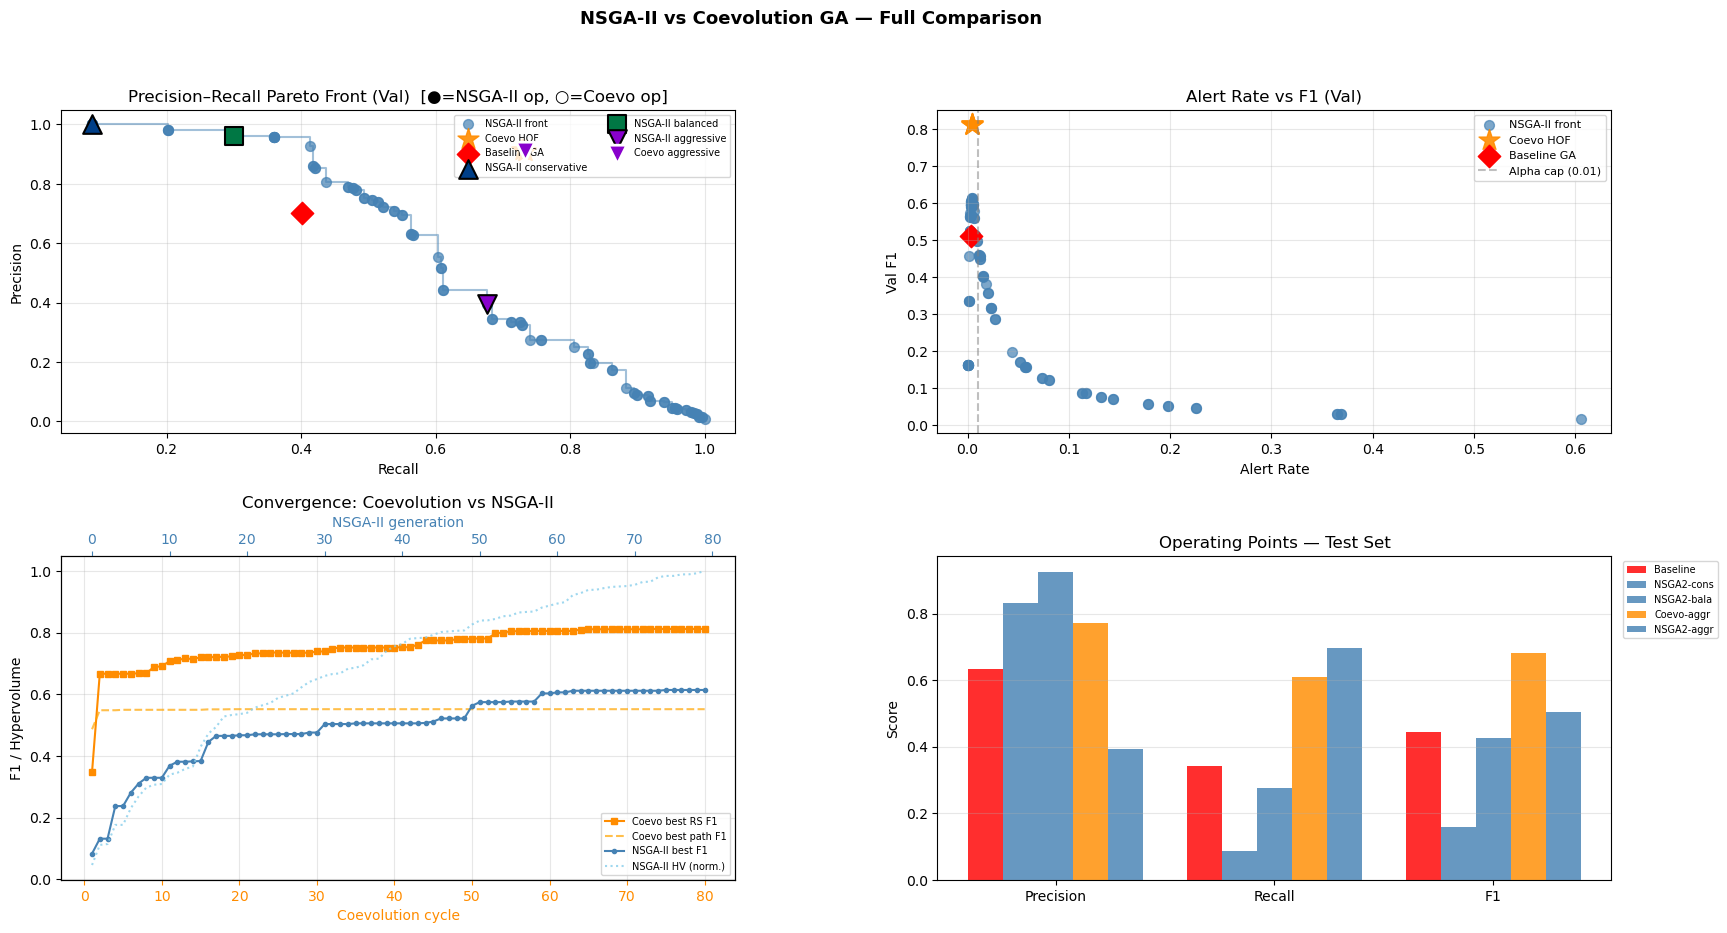

Saved to C:/Users/schyu/Downloads/OneDrive_1_3-10-2026/outputs/nsga2_vs_coevo.png

Full Method Comparison (Test Set):
              Method  Precision  Recall     F1  Alert  # Rules  # Conds
         Baseline GA     0.6341  0.3421 0.4444 0.0027        1        4
NSGA-II-conservative     0.8333  0.0877 0.1587 0.0005        4       29
    NSGA-II-balanced     0.9265  0.2763 0.4257 0.0015        4       21
    Coevo-aggressive     0.7722  0.6096 0.6814 0.0040        5       23
  NSGA-II-aggressive     0.3936  0.6974 0.5032 0.0090        5       21


In [ ]:
if RUN_NSGA2 and RUN_COEVOLUTION:

    # ── Pre-compute coevo HOF points for plotting ──────────────────────
    co_hof_rows = []
    for rs in list(rs_hof):
        vp = apply_ruleset(rs, X_val)
        m  = evaluate_metrics(y_val, vp)
        co_hof_rows.append(m)
    co_hof_df = pd.DataFrame(co_hof_rows)

    _op_markers = {"conservative": "^", "balanced": "s", "aggressive": "v"}
    _op_colors  = {"conservative": "#003f88", "balanced": "#007744", "aggressive": "#8800cc"}
    _op_names   = ["conservative", "balanced", "aggressive"]

    fig = plt.figure(figsize=(20, 10))
    gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.3)

    # ── Panel 1 (top-left): Precision vs Recall Pareto front ──────────────
    ax1 = fig.add_subplot(gs[0, 0])
    n2_sorted = nsga2_pareto_df.sort_values("recall")
    ax1.scatter(n2_sorted["recall"], n2_sorted["precision"],
                c="steelblue", s=50, alpha=0.7, zorder=3, label="NSGA-II front")
    ax1.step(n2_sorted["recall"].tolist(), n2_sorted["precision"].tolist(),
             where="post", color="steelblue", linewidth=1.5, alpha=0.5)
    ax1.scatter(co_hof_df["recall"], co_hof_df["precision"],
                c="darkorange", marker="*", s=250, alpha=0.9, zorder=4, label="Coevo HOF")
    if RUN_BASELINE_GA:
        vp_b = apply_path(best_baseline_rule, X_val).astype(int)
        bm   = evaluate_metrics(y_val, vp_b)
        ax1.scatter(bm["recall"], bm["precision"],
                    c="red", marker="D", s=130, zorder=5, label="Baseline GA")
    for name in _op_names:
        if name in nsga2_ops:
            r = nsga2_ops[name]
            ax1.scatter(r["recall"], r["precision"],
                        marker=_op_markers[name], c=_op_colors[name],
                        s=180, edgecolors="black", linewidths=1.5, zorder=6,
                        label=f"NSGA-II {name}")
        if name in operating_points:
            r = operating_points[name]
            ax1.scatter(r["recall"], r["precision"],
                        marker=_op_markers[name], c=_op_colors[name],
                        s=180, edgecolors="white", linewidths=2.0, zorder=6,
                        label=f"Coevo {name}")
    ax1.set_xlabel("Recall"); ax1.set_ylabel("Precision")
    ax1.set_title("Precision–Recall Pareto Front (Val)  [●=NSGA-II op, ○=Coevo op]")
    ax1.legend(fontsize=7, loc="upper right", ncol=2); ax1.grid(True, alpha=0.3)

    # ── Panel 2 (top-right): Alert Rate vs F1 ────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(nsga2_pareto_df["alert_rate"], nsga2_pareto_df["f1"],
                c="steelblue", s=50, alpha=0.7, label="NSGA-II front")
    ax2.scatter(co_hof_df["alert_rate"], co_hof_df["f1"],
                c="darkorange", marker="*", s=250, alpha=0.9, label="Coevo HOF")
    if RUN_BASELINE_GA:
        ax2.scatter(bm["alert_rate"], bm["f1"],
                    c="red", marker="D", s=130, label="Baseline GA")
    ax2.axvline(ALPHA, color="gray", linestyle="--", alpha=0.5,
                label=f"Alpha cap ({ALPHA})")
    ax2.set_xlabel("Alert Rate"); ax2.set_ylabel("Val F1")
    ax2.set_title("Alert Rate vs F1 (Val)")
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

    # ── Panel 3 (bottom-left): Convergence comparison ───────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3b = ax3.twiny()
    # Coevo: F1 over cycles (bottom x-axis)
    ax3.plot(coevo_history["cycle"], coevo_history["best_rs_f1"],
             color="darkorange", marker="s", markersize=4, label="Coevo best RS F1")
    ax3.plot(coevo_history["cycle"], coevo_history["best_path_f1"],
             color="orange", linestyle="--", alpha=0.7, label="Coevo best path F1")
    ax3.set_xlabel("Coevolution cycle", color="darkorange")
    ax3.tick_params(axis="x", colors="darkorange")
    ax3.set_ylabel("F1 / Hypervolume")
    # NSGA-II: best F1 + normalised HV over gens (top x-axis)
    _hv_max = nsga2_history["hypervolume"].max()
    _hv_norm = nsga2_history["hypervolume"] / (_hv_max + 1e-12)
    ax3b.plot(nsga2_history["gen"], nsga2_history["best_f1"],
              color="steelblue", marker="o", markersize=3, label="NSGA-II best F1")
    ax3b.plot(nsga2_history["gen"], _hv_norm,
              color="skyblue", linestyle=":", alpha=0.8, label="NSGA-II HV (norm.)")
    ax3b.set_xlabel("NSGA-II generation", color="steelblue")
    ax3b.tick_params(axis="x", colors="steelblue")
    lines1, labs1 = ax3.get_legend_handles_labels()
    lines2, labs2 = ax3b.get_legend_handles_labels()
    ax3.legend(lines1 + lines2, labs1 + labs2, fontsize=7, loc="lower right")
    ax3.set_title("Convergence: Coevolution vs NSGA-II")
    ax3.grid(True, alpha=0.3)

    # ── Panel 4 (bottom-right): Operating point bar chart (Test Set) ───────
    ax4 = fig.add_subplot(gs[1, 1])
    op_rows = []
    for name in _op_names:
        if name in test_op_results:
            m = test_op_results[name]
            op_rows.append({"label": f"Coevo-{name[:4]}",
                            "Precision": m["precision"], "Recall": m["recall"],
                            "F1": m["f1"], "color": "darkorange"})
        if name in nsga2_test_op_res:
            m = nsga2_test_op_res[name]
            op_rows.append({"label": f"NSGA2-{name[:4]}",
                            "Precision": m["precision"], "Recall": m["recall"],
                            "F1": m["f1"], "color": "steelblue"})
    if RUN_BASELINE_GA:
        op_rows.insert(0, {
            "label": "Baseline",
            "Precision": baseline_test_metrics["precision"],
            "Recall":    baseline_test_metrics["recall"],
            "F1":        baseline_test_metrics["f1"],
            "color":     "red",
        })
    _metrics = ["Precision", "Recall", "F1"]
    _x       = np.arange(len(_metrics))
    _w       = 0.8 / len(op_rows)
    for i, row in enumerate(op_rows):
        ax4.bar(_x + i * _w, [row[m] for m in _metrics], _w,
                label=row["label"], color=row["color"], alpha=0.82)
    ax4.set_xticks(_x + _w * (len(op_rows) - 1) / 2)
    ax4.set_xticklabels(_metrics)
    ax4.set_ylabel("Score"); ax4.set_title("Operating Points — Test Set")
    ax4.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
    ax4.grid(True, alpha=0.3, axis="y")

    fig.suptitle("NSGA-II vs Coevolution GA — Full Comparison",
                 fontsize=13, fontweight="bold")
    fig.savefig(f"{OUTPUT_DIR}/nsga2_vs_coevo.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {OUTPUT_DIR}/nsga2_vs_coevo.png")

    # ── Comparison table ───────────────────────────────────────────────────────
    comp_rows = []
    if RUN_BASELINE_GA:
        comp_rows.append({
            "Method": "Baseline GA",
            "Precision": baseline_test_metrics["precision"],
            "Recall":    baseline_test_metrics["recall"],
            "F1":        baseline_test_metrics["f1"],
            "Alert":     baseline_test_metrics["alert_rate"],
            "# Rules": 1, "# Conds": len(best_baseline_rule),
        })
    for name in _op_names:
        if name in test_op_results:
            m = test_op_results[name]
            r = operating_points[name]
            comp_rows.append({
                "Method": f"Coevo-{name}",
                "Precision": m["precision"], "Recall": m["recall"],
                "F1": m["f1"], "Alert": m["alert_rate"],
                "# Rules": int(r["n_rules"]), "# Conds": int(r["total_conditions"]),
            })
        if name in nsga2_test_op_res:
            m = nsga2_test_op_res[name]
            r = nsga2_ops[name]
            comp_rows.append({
                "Method": f"NSGA-II-{name}",
                "Precision": m["precision"], "Recall": m["recall"],
                "F1": m["f1"], "Alert": m["alert_rate"],
                "# Rules": int(r["n_rules"]), "# Conds": int(r["total_conditions"]),
            })
    comp_df = pd.DataFrame(comp_rows).round(4)
    comp_df.to_csv(f"{OUTPUT_DIR}/nsga2_vs_coevo_comparison.csv", index=False)
    print("\nFull Method Comparison (Test Set):")
    print("=" * 85)
    print(comp_df.to_string(index=False))


---
## Section 8: Greedy Rule-Set Builder (Marginal Contribution)

### Algorithm
```
S <- empty
Precompute fires[p] for every candidate path p on the validation set

Repeat:
    For each remaining path p:
        score(p|S) = NewTP(p|S) - GREEDY_LAMBDA*NewFP(p|S) - GREEDY_GAMMA*Complexity(p)
    p* = argmax score(p|S)

    if NewTP(p*|S) < GREEDY_MIN_NEW_TP:  STOP  (diminishing returns)
    if len(S) >= GREEDY_MAX_RULES:        STOP  (parsimony cap)
    S <- S union {p*}
```

**Candidate pool**: all unique paths from the co-evolution Hall-of-Fame (and path HoF).
**Fast**: fires_matrix precomputed once; all marginal TP/FP are pure numpy boolean ops.
**Post-hoc assembly**: Greedy uses GA outputs as raw material — it is not an evolutionary algorithm.

Candidate pool: 10 unique paths

Greedy Rule-Set Construction (Validation Set):
  Rule 1: NewTP= 104  NewFP=  26  Score=  75.00  CumulF1=0.5517  Alert=0.002889
    -> Transactions_Last_7d >= 7.0000  AND  Email_Domain_Age_Days <= 144.0000  AND  Days_Since_Last_Address_Change <= 48.0000  AND  Transaction_Hour <= 10.0000  AND  Session_Duration <= 648.4000  AND  Credit_Limit_Utilization > 0.0090
  Rule 2: NewTP=  38  NewFP=   3  Score=  32.50  CumulF1=0.6794  Alert=0.003800
    -> Transactions_Last_24h >= 4.0000  AND  Session_Duration <= 93.8000  AND  Geo_Location_Risk >= 32.6000  AND  Credit_Limit_Utilization >= 0.1190  AND  Time_Since_Last_Transaction < 4.2490
  Rule 3: NewTP=  17  NewFP=   1  Score=  14.00  CumulF1=0.7294  Alert=0.004200
    -> Credit_Limit_Utilization > 0.7050  AND  Geo_Location_Risk >= 42.1000  AND  IP_Risk_Score >= 28.1000  AND  Days_Since_Last_Address_Change < 538.0000
  Rule 4: NewTP=  16  NewFP=   2  Score=  11.50  CumulF1=0.7709  Alert=0.004600
    -> Days_Since_

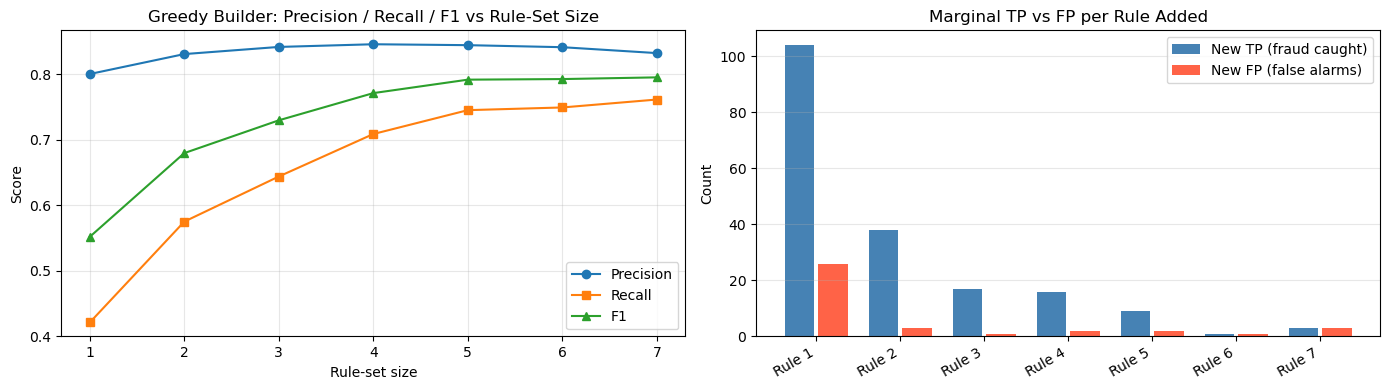

Greedy table saved: C:/Users/schyu/Downloads/OneDrive_1_3-10-2026/outputs/greedy_ruleset_table.csv
Greedy plot  saved: C:/Users/schyu/Downloads/OneDrive_1_3-10-2026/outputs/greedy_builder.png


In [ ]:
if not RUN_GREEDY:
    print("Skipping Greedy builder (RUN_GREEDY = False)")
elif not RUN_COEVOLUTION and not RUN_BASELINE_GA:
    print("Greedy builder requires at least one GA. Skipping.")
else:
    # -- Build candidate pool from coevo HoF (and path HoF) ------------------
    candidate_paths = []
    if RUN_COEVOLUTION:
        seen_keys = set()
        for rs in list(rs_hof):
            for p in rs:
                key = tuple(sorted(str(c) for c in p))
                if key not in seen_keys:
                    candidate_paths.append(list(p))
                    seen_keys.add(key)
        for p in list(path_hof):
            key = tuple(sorted(str(c) for c in p))
            if key not in seen_keys:
                candidate_paths.append(list(p))
                seen_keys.add(key)
    else:
        candidate_paths = [list(best_baseline_rule)]

    print(f"Candidate pool: {len(candidate_paths)} unique paths")

    # -- Precompute fires matrix on validation set ----------------------------
    n_val     = len(X_val)
    y_val_arr = np.asarray(y_val)
    fires_matrix = np.zeros((len(candidate_paths), n_val), dtype=bool)
    for i, path in enumerate(candidate_paths):
        fires_matrix[i] = apply_path(path, X_val)

    # -- Greedy loop ---------------------------------------------------------
    greedy_ruleset = []
    greedy_table   = []
    fires_S        = np.zeros(n_val, dtype=bool)
    remaining_idx  = list(range(len(candidate_paths)))

    print("\nGreedy Rule-Set Construction (Validation Set):")
    print("=" * 80)

    for step in range(1, GREEDY_MAX_RULES + 1):
        best_score, best_idx, best_new_tp, best_new_fp = -np.inf, -1, 0, 0

        for idx in remaining_idx:
            sc, ntp, nfp = marginal_score(
                fires_matrix[idx], fires_S, y_val_arr,
                lam=GREEDY_LAMBDA, gam=GREEDY_GAMMA,
                complexity=len(candidate_paths[idx])
            )
            if sc > best_score:
                best_score, best_idx, best_new_tp, best_new_fp = sc, idx, ntp, nfp

        if best_idx == -1 or best_new_tp < GREEDY_MIN_NEW_TP:
            print(f"  Stopped at step {step}: "
                  f"best NewTP={best_new_tp} < threshold {GREEDY_MIN_NEW_TP}")
            break

        chosen = candidate_paths[best_idx]
        greedy_ruleset.append(chosen)
        fires_S |= fires_matrix[best_idx]
        remaining_idx.remove(best_idx)

        cum_pred   = fires_S.astype(int)
        cum_prec   = precision_score(y_val_arr, cum_pred, zero_division=0)
        cum_recall = recall_score(y_val_arr, cum_pred, zero_division=0)
        cum_f1     = f1_score(y_val_arr, cum_pred, zero_division=0)
        cum_alert  = float(cum_pred.sum()) / n_val

        greedy_table.append({
            "Rule #":            step,
            "NewTP":             best_new_tp,
            "NewFP":             best_new_fp,
            "Marginal Score":    round(best_score, 3),
            "Cumul. Recall":     round(cum_recall, 4),
            "Cumul. Precision":  round(cum_prec, 4),
            "Cumul. F1":         round(cum_f1, 4),
            "Cumul. Alert Rate": round(cum_alert, 6),
            "Rule String":       pretty_path(chosen),
        })

        print(f"  Rule {step}: NewTP={best_new_tp:4d}  NewFP={best_new_fp:4d}  "
              f"Score={best_score:7.2f}  CumulF1={cum_f1:.4f}  Alert={cum_alert:.6f}")
        print(f"    -> {pretty_path(chosen)}")

    # -- Evaluate on all three splits ----------------------------------------
    greedy_table_df      = pd.DataFrame(greedy_table)
    greedy_test_pred     = apply_ruleset(greedy_ruleset, X_test)
    greedy_test_metrics  = evaluate_metrics(y_test, greedy_test_pred)
    greedy_val_pred      = fires_S.astype(int)
    greedy_val_metrics   = evaluate_metrics(y_val, greedy_val_pred)
    greedy_train_pred    = apply_ruleset(greedy_ruleset, X_train)
    greedy_train_metrics = evaluate_metrics(y_train, greedy_train_pred)

    print("\n" + "=" * 80)
    print("GREEDY RULE SET -- Final")
    print("=" * 80)
    print(pretty_ruleset(greedy_ruleset))
    print(f"  Rules: {len(greedy_ruleset)} | Conditions per rule: {[len(p) for p in greedy_ruleset]}")
    print(f"  Val  -> Prec: {greedy_val_metrics['precision']:.4f}  "
          f"Rec: {greedy_val_metrics['recall']:.4f}  F1: {greedy_val_metrics['f1']:.4f}")
    print(f"  Test -> Prec: {greedy_test_metrics['precision']:.4f}  "
          f"Rec: {greedy_test_metrics['recall']:.4f}  F1: {greedy_test_metrics['f1']:.4f}")
    print("\nGreedy addition table (validation set):")
    print(greedy_table_df.to_string(index=False))

    greedy_table_df.to_csv(f"{OUTPUT_DIR}/greedy_ruleset_table.csv", index=False)

    # -- Plot ----------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    steps = greedy_table_df["Rule #"].values
    axes[0].plot(steps, greedy_table_df["Cumul. Precision"], "o-", label="Precision")
    axes[0].plot(steps, greedy_table_df["Cumul. Recall"],    "s-", label="Recall")
    axes[0].plot(steps, greedy_table_df["Cumul. F1"],        "^-", label="F1")
    axes[0].set_xlabel("Rule-set size"); axes[0].set_ylabel("Score")
    axes[0].set_title("Greedy Builder: Precision / Recall / F1 vs Rule-Set Size")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    bar_x = np.arange(len(steps))
    axes[1].bar(bar_x - 0.2, greedy_table_df["NewTP"], 0.35,
                label="New TP (fraud caught)", color="steelblue")
    axes[1].bar(bar_x + 0.2, greedy_table_df["NewFP"], 0.35,
                label="New FP (false alarms)", color="tomato")
    axes[1].set_xticks(bar_x)
    axes[1].set_xticklabels([f"Rule {i}" for i in steps], rotation=30, ha="right")
    axes[1].set_ylabel("Count"); axes[1].set_title("Marginal TP vs FP per Rule Added")
    axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/greedy_builder.png", dpi=150)
    plt.show()
    print(f"Greedy table saved: {OUTPUT_DIR}/greedy_ruleset_table.csv")
    print(f"Greedy plot  saved: {OUTPUT_DIR}/greedy_builder.png")

---
## Section 8a: Greedy Builder — 30-Variant Hyperparameter Sweep

Sweeps a **5 × 6 grid** over two greedy knobs (GREEDY_MAX_RULES fixed at 10):

| Parameter | Values |
|---|---|
| `GREEDY_LAMBDA` | 0.1, 0.5, 1.0, 2.0, 5.0 |
| `GREEDY_GAMMA`  | 0.0, 0.25, 0.5, 1.0, 2.0, 5.0 |

Each variant reuses the **same coevolution Hall-of-Fame** (pre-computed `fires_matrix`)
from Section 8 — only the marginal-score weights change.
Results stored in `greedy_sweep_results` and saved by Section 13 (Export Results).

In [ ]:
import itertools

# -- Requires Section 8 to have run (candidate_paths + fires_matrix) ----------
_prereqs_ok = (
    RUN_GREEDY and
    "candidate_paths" in dir() and "fires_matrix" in dir()
)

if not _prereqs_ok:
    print("Section 8a requires RUN_GREEDY=True and Section 8 to have run. Skipping.")
else:
    SWEEP_LAMBDAS = [0.1, 0.5, 1.0, 2.0, 5.0]
    SWEEP_GAMMAS  = [0.0, 0.25, 0.5, 1.0, 2.0, 5.0]
    variants = list(itertools.product(SWEEP_LAMBDAS, SWEEP_GAMMAS))
    print(f"Running {len(variants)} greedy variants (GREEDY_MAX_RULES={GREEDY_MAX_RULES} fixed)...")

    y_val_sw   = np.asarray(y_val)
    y_train_sw = np.asarray(y_train)
    y_test_sw  = np.asarray(y_test)

    greedy_sweep_results = []

    for lam, gam in variants:
        vname = f"lam{lam}_gam{gam}"

        fires_S_v   = np.zeros(len(X_val), dtype=bool)
        remaining_v = list(range(len(candidate_paths)))
        greedy_rs_v = []

        for _ in range(GREEDY_MAX_RULES):
            best_sc, best_idx_v, best_ntp = -np.inf, -1, 0
            for idx in remaining_v:
                sc, ntp, _ = marginal_score(
                    fires_matrix[idx], fires_S_v, y_val_sw,
                    lam=lam, gam=gam,
                    complexity=len(candidate_paths[idx])
                )
                if sc > best_sc:
                    best_sc, best_idx_v, best_ntp = sc, idx, ntp

            if best_idx_v == -1 or best_ntp < GREEDY_MIN_NEW_TP:
                break

            greedy_rs_v.append(candidate_paths[best_idx_v])
            fires_S_v |= fires_matrix[best_idx_v]
            remaining_v.remove(best_idx_v)

        if not greedy_rs_v:
            print(f"  {vname}: no rules selected -- skipping")
            continue

        def _eval_sw(rs, X, y):
            return evaluate_metrics(y, apply_ruleset(rs, X))

        m_tr = _eval_sw(greedy_rs_v, X_train, y_train_sw)
        m_va = _eval_sw(greedy_rs_v, X_val,   y_val_sw)
        m_te = _eval_sw(greedy_rs_v, X_test,  y_test_sw)

        n_r = len(greedy_rs_v)
        n_c = sum(len(p) for p in greedy_rs_v)
        print(f"  {vname:25s} | rules={n_r} conds={n_c:2d} "
              f"| val_F1={m_va['f1']:.4f}  test_F1={m_te['f1']:.4f}")

        greedy_sweep_results.append({
            "model":             "Greedy Builder",
            "variant":           vname,
            "crossover":         None,
            "mutation":          None,
            "selection":         None,
            "coverage_lambda":   lam,
            "parsimony_mu":      gam,
            "pop_size":          None,
            "cx_prob":           None,
            "max_budget":        GREEDY_MAX_RULES,
            "converged_at":      n_r,
            "n_paths":           n_r,
            "total_conditions":  n_c,
            "train_precision":   m_tr["precision"],
            "train_recall":      m_tr["recall"],
            "train_f1":          m_tr["f1"],
            "train_alert_rate":  m_tr["alert_rate"],
            "val_precision":     m_va["precision"],
            "val_recall":        m_va["recall"],
            "val_f1":            m_va["f1"],
            "val_alert_rate":    m_va["alert_rate"],
            "test_precision":    m_te["precision"],
            "test_recall":       m_te["recall"],
            "test_f1":           m_te["f1"],
            "test_alert_rate":   m_te["alert_rate"],
            "best_rule_str":    pretty_ruleset(greedy_rs_v),
        })

    print(f"\nGreedy sweep complete: {len(greedy_sweep_results)} variants collected.")
    if greedy_sweep_results:
        _best = max(greedy_sweep_results, key=lambda r: r["test_f1"])
        print(f"Best variant (test F1={_best['test_f1']:.4f}): {_best['variant']}")

Running 30 greedy variants (GREEDY_MAX_RULES=10 fixed)...
  lam0.1_gam0.0             | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.1_gam0.25            | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.1_gam0.5             | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.1_gam1.0             | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.1_gam2.0             | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.1_gam5.0             | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.5_gam0.0             | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.5_gam0.25            | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.5_gam0.5             | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.5_gam1.0             | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.5_gam2.0             | rules=7 conds=34 | val_F1=0.7949  test_F1=0.6790
  lam0.5_gam5.0             | rules=7 conds=34 | val_F1=0.7949  test_F1=0

---
## Section 9: Multi-Seed Stability Analysis

Run the coevolution GA across 5 seeds to validate that results are reproducible.


In [ ]:
if not RUN_STABILITY:
    print("Skipping stability analysis (RUN_STABILITY = False)")
elif not RUN_COEVOLUTION:
    print("Skipping stability analysis (requires RUN_COEVOLUTION = True)")
else:
    print(f"Running stability analysis across seeds: {STABILITY_SEEDS}")
    print("=" * 60)
    stability_results = {}
    for seed in STABILITY_SEEDS:
        print(f"\nSeed {seed}:")
        _, best_rs_seed, _, _, rs_hof_seed = run_coevolution(seed=seed)
        seed_pareto_rows = []
        for rs in list(rs_hof_seed):
            vp = apply_ruleset(rs, X_val)
            m  = evaluate_metrics(y_val, vp)
            seed_pareto_rows.append({
                "precision": m["precision"], "recall": m["recall"],
                "f1": m["f1"], "alert_rate": m["alert_rate"],
                "n_rules": len(rs), "total_conditions": sum(len(p) for p in rs),
                "rule_set_string": pretty_ruleset(rs), "ruleset_obj": rs,
            })
        seed_pareto = pd.DataFrame(seed_pareto_rows)
        seed_ops    = select_operating_points(seed_pareto)
        for name, row in seed_ops.items():
            rs = row["ruleset_obj"]
            tp = apply_ruleset(rs, X_test)
            m  = evaluate_metrics(y_test, tp)
            stability_results.setdefault(name, []).append(
                {"seed": seed, **{k: v for k, v in m.items() if k in
                                   ["precision", "recall", "f1", "alert_rate"]}}
            )
    print("\n" + "=" * 70)
    print("STABILITY SUMMARY (TEST metrics across 5 seeds)")
    print("=" * 70)
    stab_rows = []
    for name, records in stability_results.items():
        df_s = pd.DataFrame(records)
        row  = {"operating_point": name, "n_seeds": len(df_s)}
        for metric in ["precision", "recall", "f1", "alert_rate"]:
            row[f"{metric}_mean"] = df_s[metric].mean()
            row[f"{metric}_std"]  = df_s[metric].std()
        stab_rows.append(row)
        print(f"\n[{name.upper()}]")
        print(f"  Precision: {row['precision_mean']:.4f} +/- {row['precision_std']:.4f}")
        print(f"  Recall:    {row['recall_mean']:.4f} +/- {row['recall_std']:.4f}")
        print(f"  F1:        {row['f1_mean']:.4f} +/- {row['f1_std']:.4f}")
        print(f"  Alert:     {row['alert_rate_mean']:.4f} +/- {row['alert_rate_std']:.4f}")
    stability_df = pd.DataFrame(stab_rows)
    stability_df.to_csv(f"{OUTPUT_DIR}/stability_metrics.csv", index=False)
    print(f"\nStability metrics saved to {OUTPUT_DIR}/stability_metrics.csv")


Running stability analysis across seeds: [11, 22, 33, 44, 55]

Seed 11:
  Seed=11 | 60 paths, 40 rule sets, 80 cycles
  Cycle  2/80 | Path F1: 0.5198 | RS F1: 0.3958 | Paths: 3 | Alert: 0.0092
  Cycle  4/80 | Path F1: 0.5490 | RS F1: 0.5267 | Paths: 3 | Alert: 0.0053
  Cycle  6/80 | Path F1: 0.5490 | RS F1: 0.6014 | Paths: 4 | Alert: 0.0038
  Cycle  8/80 | Path F1: 0.5490 | RS F1: 0.7044 | Paths: 4 | Alert: 0.0051
  Cycle 10/80 | Path F1: 0.5490 | RS F1: 0.7227 | Paths: 4 | Alert: 0.0051
  Cycle 12/80 | Path F1: 0.5490 | RS F1: 0.7379 | Paths: 4 | Alert: 0.0055
  Cycle 14/80 | Path F1: 0.5490 | RS F1: 0.7381 | Paths: 4 | Alert: 0.0053
  Cycle 16/80 | Path F1: 0.5490 | RS F1: 0.7392 | Paths: 4 | Alert: 0.0053
  Cycle 18/80 | Path F1: 0.5490 | RS F1: 0.7431 | Paths: 4 | Alert: 0.0050
  Cycle 20/80 | Path F1: 0.5490 | RS F1: 0.7457 | Paths: 4 | Alert: 0.0048
  Cycle 22/80 | Path F1: 0.5490 | RS F1: 0.7516 | Paths: 4 | Alert: 0.0050
  Cycle 24/80 | Path F1: 0.5490 | RS F1: 0.7623 | Paths: 

---
## Section 10: Pareto Front Visualizations


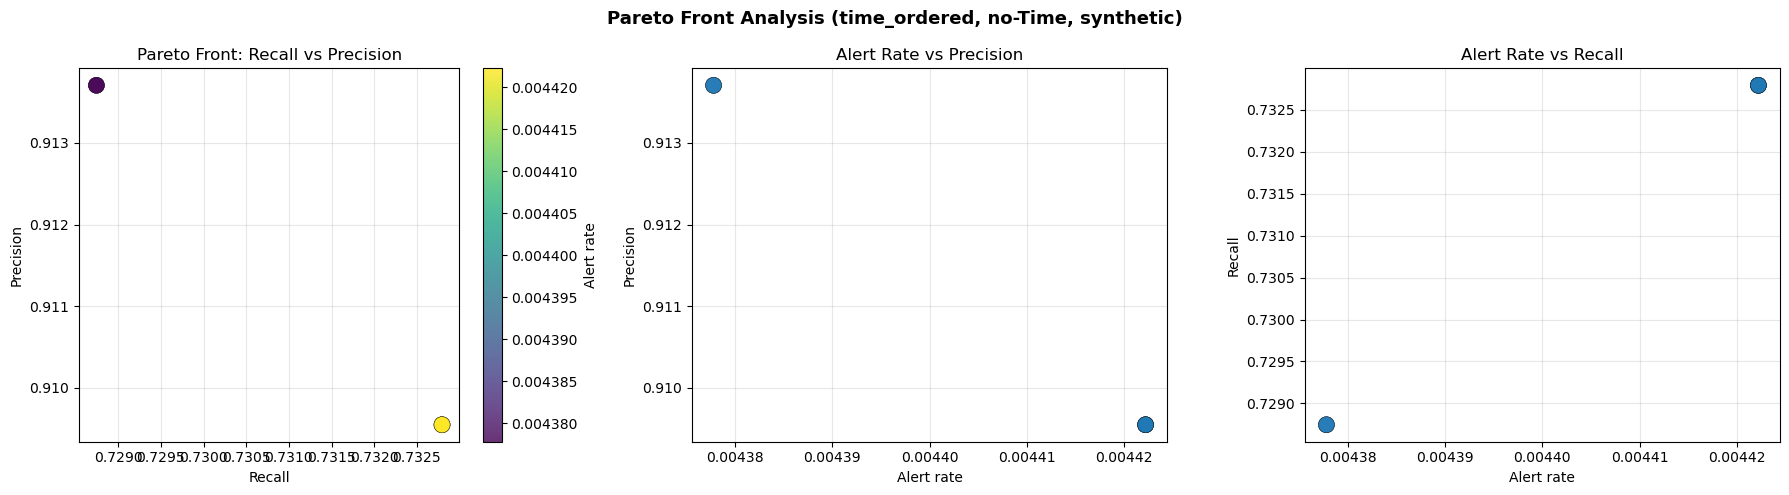

In [ ]:
if RUN_COEVOLUTION:
    df_plot = pd.read_csv(f"{OUTPUT_DIR}/pareto_front.csv")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sc = axes[0].scatter(
        df_plot["recall"], df_plot["precision"],
        c=df_plot["alert_rate"], s=20 + 5 * df_plot["total_conditions"],
        cmap="viridis", alpha=0.8, edgecolors="k", linewidths=0.3
    )
    plt.colorbar(sc, ax=axes[0]).set_label("Alert rate")
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
    axes[0].set_title("Pareto Front: Recall vs Precision")
    axes[0].grid(True, alpha=0.3)
    axes[1].scatter(df_plot["alert_rate"], df_plot["precision"],
        s=20 + 5 * df_plot["total_conditions"], alpha=0.8, edgecolors="k", linewidths=0.3)
    axes[1].set_xlabel("Alert rate"); axes[1].set_ylabel("Precision")
    axes[1].set_title("Alert Rate vs Precision")
    axes[1].grid(True, alpha=0.3)
    axes[2].scatter(df_plot["alert_rate"], df_plot["recall"],
        s=20 + 5 * df_plot["total_conditions"], alpha=0.8, edgecolors="k", linewidths=0.3)
    axes[2].set_xlabel("Alert rate"); axes[2].set_ylabel("Recall")
    axes[2].set_title("Alert Rate vs Recall")
    axes[2].grid(True, alpha=0.3)
    suffix = f"({SPLIT_MODE}, {'no-Time' if EXCLUDE_TIME_FEATURES else 'with-Time'}, synthetic)"
    fig.suptitle(f"Pareto Front Analysis {suffix}", fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/pareto_plots.png", dpi=150)
    plt.show()


---
## Section 11: Baseline vs Coevolution Comparison


METHOD COMPARISON (Test Set)
                        Method  Precision  Recall     F1  Alert Rate  # Rules  # Conditions
     Baseline GA (single rule)     0.6341  0.3421 0.4444      0.0027        1             4
Coevolution GA (best rule set)     0.7722  0.6096 0.6814      0.0040        5            23
     Coevolution -- aggressive     0.7722  0.6096 0.6814      0.0040        5            23
       NSGA-II -- conservative     0.8333  0.0877 0.1587      0.0005        4            29
           NSGA-II -- balanced     0.9265  0.2763 0.4257      0.0015        4            21
         NSGA-II -- aggressive     0.3936  0.6974 0.5032      0.0090        5            21
                Greedy Builder     0.7171  0.6447 0.6790      0.0046        7            34


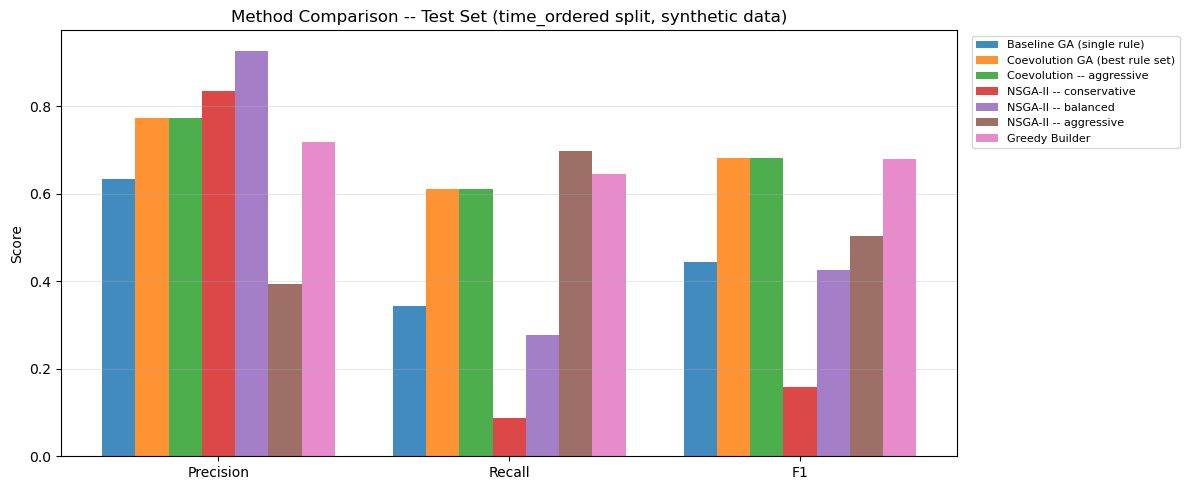

In [ ]:
if RUN_BASELINE_GA and RUN_COEVOLUTION:
    print("METHOD COMPARISON (Test Set)")
    print("=" * 70)
    comp_data = [
        {"Method": "Baseline GA (single rule)",
         "Precision": baseline_test_metrics["precision"],
         "Recall":    baseline_test_metrics["recall"],
         "F1":        baseline_test_metrics["f1"],
         "Alert Rate":baseline_test_metrics["alert_rate"],
         "# Rules":   1,
         "# Conditions": len(best_baseline_rule)},
        {"Method": "Coevolution GA (best rule set)",
         "Precision": co_test_metrics["precision"],
         "Recall":    co_test_metrics["recall"],
         "F1":        co_test_metrics["f1"],
         "Alert Rate":co_test_metrics["alert_rate"],
         "# Rules":   len(best_ruleset),
         "# Conditions": sum(len(p) for p in best_ruleset)},
    ]
    for name, row in test_op_results.items():
        op_row = operating_points[name]
        comp_data.append({
            "Method": f"Coevolution -- {name}",
            "Precision": row["precision"], "Recall": row["recall"],
            "F1": row["f1"], "Alert Rate": row["alert_rate"],
            "# Rules": int(op_row["n_rules"]),
            "# Conditions": int(op_row["total_conditions"]),
        })
    # -- NSGA-II rows --
    if RUN_NSGA2:
        for name in ["conservative", "balanced", "aggressive"]:
            if name in nsga2_test_op_res:
                m   = nsga2_test_op_res[name]
                row = nsga2_ops[name]
                comp_data.append({
                    "Method":      f"NSGA-II -- {name}",
                    "Precision":   m["precision"],
                    "Recall":      m["recall"],
                    "F1":          m["f1"],
                    "Alert Rate":  m["alert_rate"],
                    "# Rules":     int(row["n_rules"]),
                    "# Conditions": int(row["total_conditions"]),
                })
    # -- Greedy Builder row --
    if RUN_GREEDY and "greedy_test_metrics" in dir():
        comp_data.append({
            "Method":      "Greedy Builder",
            "Precision":   greedy_test_metrics["precision"],
            "Recall":      greedy_test_metrics["recall"],
            "F1":          greedy_test_metrics["f1"],
            "Alert Rate":  greedy_test_metrics["alert_rate"],
            "# Rules":     len(greedy_ruleset),
            "# Conditions": sum(len(p) for p in greedy_ruleset),
        })

    comp_df = pd.DataFrame(comp_data).round(4)
    comp_df.to_csv(f"{OUTPUT_DIR}/method_comparison.csv", index=False)
    print(comp_df.to_string(index=False))
    metrics_to_plot = ["Precision", "Recall", "F1"]
    x     = np.arange(len(metrics_to_plot))
    width = 0.8 / len(comp_df)
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (_, row) in enumerate(comp_df.iterrows()):
        ax.bar(x + i * width, [row[m] for m in metrics_to_plot], width, label=row["Method"], alpha=0.85)
    ax.set_xticks(x + width * (len(comp_df) - 1) / 2)
    ax.set_xticklabels(metrics_to_plot)
    ax.set_ylabel("Score")
    ax.set_title(f"Method Comparison -- Test Set ({SPLIT_MODE} split, synthetic data)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/method_comparison.png", dpi=150)
    plt.show()

---
## Section 12: No-Time Leak Verification

Confirm that the simulated `Time` column does not appear in any evolved rule.


In [ ]:
if EXCLUDE_TIME_FEATURES and RUN_COEVOLUTION:
    patterns   = {f: re.compile(r"\b" + re.escape(f) + r"\b") for f in TIME_FEATURES}
    leak_found = False
    all_rule_strings = [row["rule_set_string"] for _, row in pareto_df.iterrows()]
    for rule_str in all_rule_strings:
        for feat, pat in patterns.items():
            if pat.search(rule_str):
                print(f"LEAK DETECTED: '{feat}' found in rule: {rule_str}")
                leak_found = True
    if not leak_found:
        print("PASS: No Time features found in any evolved rule. "
              "Rules reference only interpretable transaction features.")
else:
    print("Leak check skipped (Time features not excluded or coevolution not run).")


PASS: No Time features found in any evolved rule. Rules reference only interpretable transaction features.


---
## Section 13: Export Results


In [ ]:
results_summary = {
    "config": {
        "dataset":               DATA_FILE,
        "split_mode":            SPLIT_MODE,
        "exclude_time_features": EXCLUDE_TIME_FEATURES,
        "top_k_features":        TOP_K,
        "top_features":          TOP_FEATURES,
        "random_seed":           RANDOM_SEED,
        "stability_seeds":       STABILITY_SEEDS,
        "categorical_columns":   CAT_COLS,
        "binned_feature":        BIN_FEATURE_OUT,
    }
}

if RUN_BASELINE_GA:
    results_summary["baseline_ga"] = {
        "best_rule":    pretty_path(best_baseline_rule),
        "n_conditions": len(best_baseline_rule),
        "operators": {
            "crossover": "SwapCX",
            "mutation":  "ThresholdBiasedMut",
            "selection": "Tournament3",
        },
        "train_metrics": {k: float(v) for k, v in baseline_train_metrics.items()
                          if k not in ["TP","FP","FN","TN"]},
        "val_metrics":   {k: float(v) for k, v in baseline_val_metrics.items()
                          if k not in ["TP","FP","FN","TN"]},
        "test_metrics":  {k: float(v) for k, v in baseline_test_metrics.items()
                          if k not in ["TP","FP","FN","TN"]},
    }

if RUN_COEVOLUTION:
    results_summary["coevolution_ga"] = {
        "best_ruleset":   pretty_ruleset(best_ruleset),
        "n_paths":        len(best_ruleset),
        "nodes_per_path": [len(p) for p in best_ruleset],
        "operators": {
            "path_crossover":    "cx_paths_co (swap condition)",
            "path_mutation":     "mutate_path_co (thr/flip/replace/add_node/drop_node)",
            "ruleset_crossover": "cx_rulesets_co (swap path)",
            "ruleset_mutation":  "mutate_ruleset_co (add_path/drop_path/mutate_node)",
            "selection":         "Tournament3",
        },
        "train_metrics":  {k: float(v) for k, v in co_train_metrics.items()
                           if k not in ["TP","FP","FN","TN"]},
        "val_metrics":    {k: float(v) for k, v in co_val_metrics.items()
                           if k not in ["TP","FP","FN","TN"]},
        "test_metrics":   {k: float(v) for k, v in co_test_metrics.items()
                           if k not in ["TP","FP","FN","TN"]},
        "operating_points": {
            name: {k: float(v) for k, v in m.items() if k not in ["TP","FP","FN","TN"]}
            for name, m in test_op_results.items()
        }
    }

if RUN_NSGA2 and RUN_COEVOLUTION:
    results_summary["nsga2_ga"] = {
        "operators": {
            "crossover": "cx_rulesets_co (swap path)",
            "mutation":  "mutate_ruleset_co (add_path/drop_path/mutate_node)",
            "selection": "NSGA2 TournamentDCD + selNSGA2",
            "fitness":   "(Precision, Recall) multi-objective",
        },
        "pareto_front_size": len(nsga2_pareto_df),
        "operating_points": {
            name: {
                "train_metrics": {k: float(v) for k, v in nsga2_train_op_res[name].items()
                                  if k not in ["TP","FP","FN","TN"]},
                "val_metrics":   {k: float(v) for k, v in nsga2_ops[name].items()
                                  if k not in ["TP","FP","FN","TN","ruleset_obj",
                                               "n_rules","total_conditions","rule_set_string"]},
                "test_metrics":  {k: float(v) for k, v in nsga2_test_op_res[name].items()
                                  if k not in ["TP","FP","FN","TN"]},
            }
            for name in nsga2_test_op_res
        }
    }

if RUN_GREEDY and "greedy_test_metrics" in dir():
    results_summary["greedy_builder"] = {
        "best_ruleset":   pretty_ruleset(greedy_ruleset),
        "n_paths":        len(greedy_ruleset),
        "nodes_per_path": [len(p) for p in greedy_ruleset],
        "hyperparameters": {
            "lambda":    GREEDY_LAMBDA,
            "gamma":     GREEDY_GAMMA,
            "max_rules": GREEDY_MAX_RULES,
            "min_new_tp": GREEDY_MIN_NEW_TP,
        },
        "train_metrics": {k: float(v) for k, v in greedy_train_metrics.items()
                          if k not in ["TP","FP","FN","TN"]},
        "val_metrics":   {k: float(v) for k, v in greedy_val_metrics.items()
                          if k not in ["TP","FP","FN","TN"]},
        "test_metrics":  {k: float(v) for k, v in greedy_test_metrics.items()
                          if k not in ["TP","FP","FN","TN"]},
    }

output_path = f"{OUTPUT_DIR}/results_summary.json"
with open(output_path, "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"Results summary saved to: {output_path}")
print(f"\nAll outputs in: {OUTPUT_DIR}/")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    print(f"  {fname:<50s}  {os.path.getsize(fpath)/1024:.1f} KB")

Results summary saved to: C:/Users/schyu/Downloads/OneDrive_1_3-10-2026/outputs/results_summary.json

All outputs in: C:/Users/schyu/Downloads/OneDrive_1_3-10-2026/outputs/
  all_model_results.csv                               59.1 KB
  baseline_convergence.png                            47.8 KB
  coevo_convergence.png                               66.1 KB
  greedy_builder.png                                  84.8 KB
  greedy_ruleset_table.csv                            1.6 KB
  method_comparison.csv                               0.4 KB
  method_comparison.png                               55.3 KB
  nsga2_convergence.png                               99.4 KB
  nsga2_pareto_front.csv                              125.0 KB
  nsga2_vs_coevo.png                                  233.9 KB
  nsga2_vs_coevo_comparison.csv                       0.3 KB
  pareto_front.csv                                    9.4 KB
  pareto_plots.png                                    99.8 KB
  results_summary.json 

In [ ]:

# ============================================================
# SAVE ALL MODEL RESULTS -> all_model_results.csv
# 105 Baseline GA grid + 30 Coevolution GA + 30 NSGA-II + 30 Greedy Builder = 195 rows
#
# Parameter columns (family-specific, NaN elsewhere):
#   Baseline GA    -> crossover, mutation, selection
#   Coevo GA       -> coverage_lambda, parsimony_mu
#   NSGA-II        -> pop_size, cx_prob
#   Greedy Builder -> coverage_lambda (lambda), parsimony_mu (gamma)
# Shared columns: max_budget, converged_at, n_paths, total_conditions
# ============================================================
_all_rows = []

# --- Baseline GA grid search (105 rows) ---
if RUN_BASELINE_GRID and RUN_BASELINE_GA and 'grid_results' in dir():
    for r in grid_results:
        _all_rows.append({
            "model":            "Baseline GA",
            "variant":          f"{r['cx']}_{r['mut']}_{r['sel']}",
            "crossover":        r["cx"],
            "mutation":         r["mut"],
            "selection":        r["sel"],
            "coverage_lambda":  None,
            "parsimony_mu":     None,
            "pop_size":         None,
            "cx_prob":          None,
            "max_budget":       None,
            "converged_at":     None,
            "n_paths":          None,
            "total_conditions": None,
            "train_precision":  r["train_precision"],
            "train_recall":     r["train_recall"],
            "train_f1":         r["train_f1"],
            "train_alert_rate": r["train_alert_rate"],
            "val_precision":    r["val_precision"],
            "val_recall":       r["val_recall"],
            "val_f1":           r["val_f1"],
            "val_alert_rate":   r["val_alert_rate"],
            "test_precision":   r["test_precision"],
            "test_recall":      r["test_recall"],
            "test_f1":          r["test_f1"],
            "test_alert_rate":  r["test_alert_rate"],
            "best_rule_str":   r.get("rule"),
        })

# --- Coevolution GA sweep (30 rows) ---
if RUN_COEVOLUTION and 'coevo_sweep_results' in dir():
    for r in coevo_sweep_results:
        _all_rows.append({
            **r,
            "crossover": None,
            "mutation":  None,
            "selection": None,
        })

# --- NSGA-II sweep (30 rows) ---
if RUN_NSGA2 and RUN_COEVOLUTION and 'nsga2_sweep_results' in dir():
    for r in nsga2_sweep_results:
        _all_rows.append({
            **r,
            "crossover": None,
            "mutation":  None,
            "selection": None,
        })

# --- Greedy Builder sweep (30 rows) ---
if RUN_GREEDY and 'greedy_sweep_results' in dir():
    for r in greedy_sweep_results:
        _all_rows.append(r)

if _all_rows:
    _col_order = [
        "model", "variant",
        "crossover", "mutation", "selection",
        "coverage_lambda", "parsimony_mu",
        "pop_size", "cx_prob",
        "max_budget", "converged_at",
        "n_paths", "total_conditions",
        "train_precision", "train_recall", "train_f1", "train_alert_rate",
        "val_precision",   "val_recall",   "val_f1",   "val_alert_rate",
        "test_precision",  "test_recall",  "test_f1",  "test_alert_rate",
        "best_rule_str",
    ]
    all_model_results_df = pd.DataFrame(_all_rows)[_col_order]
    _out = f"{OUTPUT_DIR}/all_model_results.csv"
    all_model_results_df.to_csv(_out, index=False)

    counts = all_model_results_df["model"].value_counts()
    print(f"Saved {len(all_model_results_df)} rows -> {_out}")
    for m, c in counts.items():
        print(f"  {m}: {c} variants")
    print()
    print(all_model_results_df[["model","variant","converged_at","val_f1","test_f1"]].to_string(index=False))
else:
    print("No results found -- run the model cells above first.")

Saved 195 rows -> C:/Users/schyu/Downloads/OneDrive_1_3-10-2026/outputs/all_model_results.csv
  Baseline GA: 105 variants
  Coevolution GA: 30 variants
  NSGA-II: 30 variants
  Greedy Builder: 30 variants

         model                                        variant  converged_at   val_f1  test_f1
   Baseline GA                  SwapCX_UniformMut_Tournament3           NaN 0.508671 0.484472
   Baseline GA                  SwapCX_UniformMut_Tournament5           NaN 0.522167 0.487252
   Baseline GA                      SwapCX_UniformMut_selBest           NaN 0.454054 0.371951
   Baseline GA                    SwapCX_UniformMut_selRandom           NaN 0.428571 0.438710
   Baseline GA                  SwapCX_UniformMut_selRoulette           NaN 0.520971 0.495192
   Baseline GA          SwapCX_ThresholdBiasedMut_Tournament3           NaN 0.533333 0.492228
   Baseline GA          SwapCX_ThresholdBiasedMut_Tournament5           NaN 0.516854 0.479769
   Baseline GA              SwapCX_Thresho